In [2]:
import matplotlib.pyplot as plt
import astricaltools as at
import numpy as np
import pandas as pd
import scipy.stats as sc
from astropy import stats
import astropy.units as u
from astropy.io import fits
from astropy.table import vstack, Table
from astropy.time import Time
from astropy.timeseries import TimeSeries
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, Angle

In [3]:
file_numbers = range(1, 10)  # da 001 a 009
base_path = "astri_{:03d}_43_009_00002_R_200101_001_0201_SEB.lv0"  # pattern del nome file

dfs = []  # lista per accumulare i DataFrame
print("\n")
for i in file_numbers:
    filename = base_path.format(i)
    print(f"{filename}")

    with at.io.fits.AstriFits(filename) as hdul:
        data = hdul[1].data

        # Conversione dei campi
        time_ns = data["TIME_NS"].byteswap().newbyteorder().astype(np.int64)
        time_s  = data["TIME_S"].byteswap().newbyteorder().astype(np.int64)
        event   = data["EVTNUM"].byteswap().newbyteorder().astype(np.int64)
        mcrun   = data["MCRUNNUM"].byteswap().newbyteorder().astype(np.int64)
        ntel= data["NTRIGTEL"]
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
        hg, lg, ttp = hdul.get_data('events', ['hi', 'lo', 'ttp'])
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
            #creo il dataframe
        df = pd.DataFrame({
                "TIME_NS": time_ns,
                "TIME_S": time_s,
                "TIME_ABS": time_abs,
                "EVENT": event,
                "MCRUN": mcrun,
                "TEL_ID": i,
                "num_tel": ntel,
                "HG": list(hg),             
                "LG": list(lg),
                "TTP": list(ttp),
            })

        dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True)
df_all_sorted= df_all.sort_values(by="TIME_ABS").reset_index(drop=True)
#mask=df_all_sorted["HG"]>2400
df_all_sorted["shape"] = df_all_sorted["HG"].apply(np.sum).to_numpy()




astri_001_43_009_00002_R_200101_001_0201_SEB.lv0
astri_002_43_009_00002_R_200101_001_0201_SEB.lv0
astri_003_43_009_00002_R_200101_001_0201_SEB.lv0
astri_004_43_009_00002_R_200101_001_0201_SEB.lv0
astri_005_43_009_00002_R_200101_001_0201_SEB.lv0
astri_006_43_009_00002_R_200101_001_0201_SEB.lv0
astri_007_43_009_00002_R_200101_001_0201_SEB.lv0
astri_008_43_009_00002_R_200101_001_0201_SEB.lv0
astri_009_43_009_00002_R_200101_001_0201_SEB.lv0


In [4]:
#======================= TAGLI ==============================
df_all_sorted = df_all_sorted[df_all_sorted["shape"] > 5.16e6]
min_pixels = 15

def count_valid_pixels(row):
    hgev = np.array(row["HG"])
    ttpev = np.array(row["TTP"])
    pxmask = (hgev > 2400) & (ttpev < 255)
    return np.sum(pxmask)

df_all_sorted["n_valid_pixels"] = df_all_sorted.apply(count_valid_pixels, axis=1)
df_all_sorted = df_all_sorted[df_all_sorted["n_valid_pixels"] >= min_pixels].reset_index(drop=True)

#====================================================================
df_all_sorted["time_group"] = (
    (df_all_sorted[["EVENT", "MCRUN"]] !=
     df_all_sorted[["EVENT", "MCRUN"]].shift())
    .any(axis=1)
    .cumsum()
)
df_all_sorted["time_group"] = (df_all_sorted["time_group"] - 1) // 2 + 1
df_all_sorted = df_all_sorted.drop_duplicates(
    subset=["time_group", "TEL_ID"],
    keep="first"
)
df_linked_events= df_all_sorted[df_all_sorted.groupby("time_group")["TEL_ID"].transform("count") > 2]

valid_groups = (
    df_linked_events
    .groupby("time_group")[["EVENT", "MCRUN"]]
    .apply(lambda g: g.drop_duplicates().shape[0] >= 2)
)

df_linked_events = df_linked_events[df_linked_events["time_group"].isin(
    valid_groups[valid_groups].index
)]
print(f"Time group dopo tagli: {df_linked_events['time_group'].nunique()}")

#df_linked_events.groupby("time_group")[["EVENT", "MCRUN"]].nunique()


Time group dopo tagli: 447


In [5]:
# ======================= FUNZIONI GEOMETRICHE =======================
def intersection(p1, d1, p2, d2, eps_ang=1e-1, eps_det=1e-6):
    """
    p1, p2 = punti (2,)
    d1, d2 = direzioni (2,)
    """

    # --- controllo quasi-parallelismo ---
    det_dir = d1[0]*d2[1] - d1[1]*d2[0]
    if abs(det_dir) < eps_ang:        # <<< taglio fisico
        return None

    A = np.array([d1, -d2]).T
    b = p2 - p1

    detA = np.linalg.det(A)
    if abs(detA) < eps_det:           # <<< sicurezza numerica
        return None

    t = np.linalg.solve(A, b)[0]
    return p1 + t * d1
def d_punto_retta(P, p0, d):
    norm_d = np.linalg.norm(d)
    if norm_d == 0:
        return np.nan
    d_unit = d / norm_d
    v = P - p0
    return abs(v[0] * d_unit[1] - v[1] * d_unit[0])
def d_punto_retta_vec(P, p0, d):
    """
    distanza di N rette da un punto
    """
    norm_d = np.linalg.norm(d, axis=1)
    mask = norm_d > 0
    d_unit = np.zeros_like(d)
    d_unit[mask] = d[mask] / norm_d[mask, None]
    v = P - p0
    return np.abs(v[:, 0] * d_unit[:, 1] - v[:, 1] * d_unit[:, 0])
def principal_axis(cov):
            l1 = (cov[0,0] + cov[1,1])/2 + np.sqrt(
                ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
            theta = np.arctan2(l1 - cov[0,0], cov[0,1])
            return l1, theta


In [6]:
xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

results = []

for time_group, df_evt in df_linked_events.groupby('time_group'):
    
    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        event = row["EVENT"]     
        mcrun = row["MCRUN"]     
        
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        if np.sum(pxmask) < 2:
            continue
        n_pixels = np.sum(pxmask)
        # SIGMA-CLIPPING
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)

        l1_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, theta_lg = principal_axis(cov_lg)

        results.append({
            "time_group": int(time_group),
            "event": int(event),      
            "mcrun": int(mcrun),   
            "n_pixels": int(n_pixels),  
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "tel": int(itel)       
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "tel": int(itel)       
            }
        })

print(f"Creati {len(results)} risultati")
dfR = pd.DataFrame(results)
print(dfR.columns)


Creati 2227 risultati
Index(['time_group', 'event', 'mcrun', 'n_pixels', 'HG', 'LG'], dtype='object')



TIME GROUP 1
Telescopi: 5 | Eventi MC: [1007 3007] | MCRUN: [220000]
Cluster DBSCAN trovati: [0]


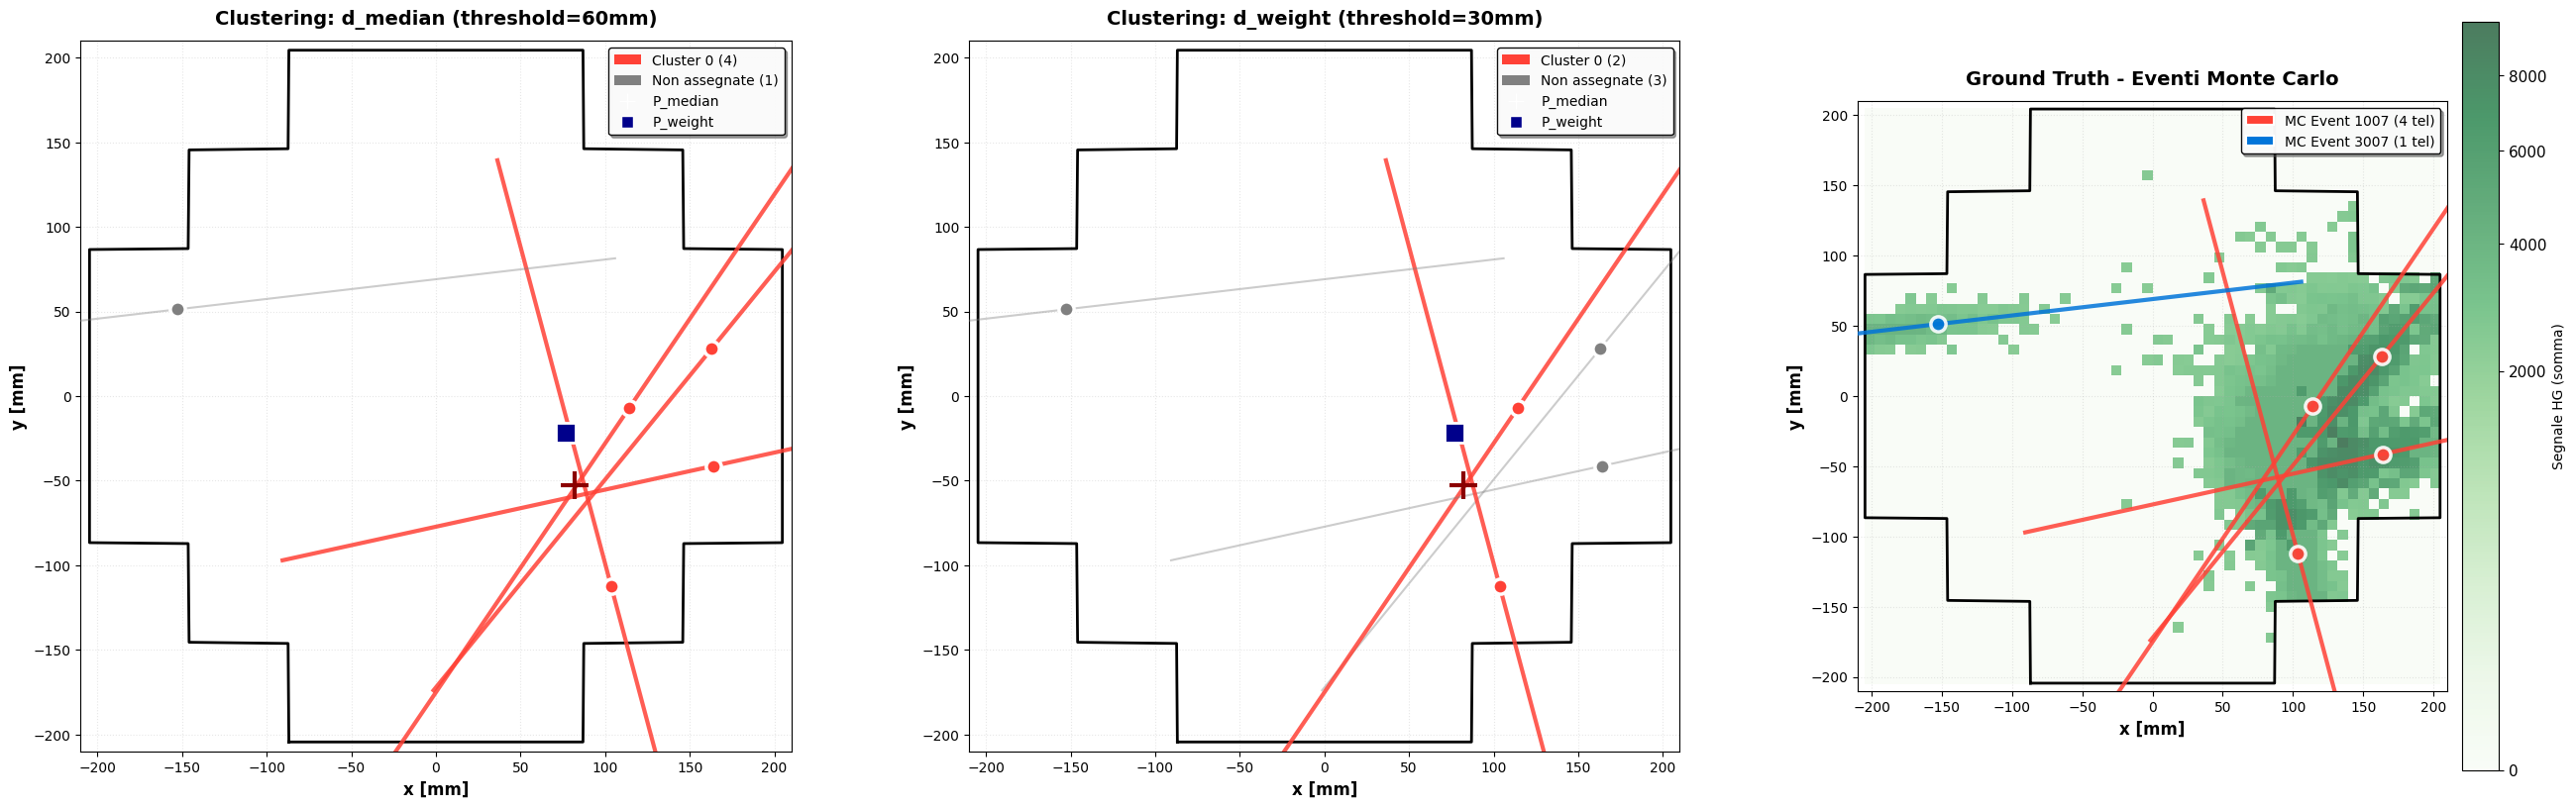

 time_group 1
  Rette totali: 5
  d_median: 5/5 corrette (100.0%)
  d_weight: 3/5 corrette (60.0%)

TIME GROUP 4
Telescopi: 6 | Eventi MC: [10109 15908] | MCRUN: [220000]
Cluster DBSCAN trovati: [0, 1]


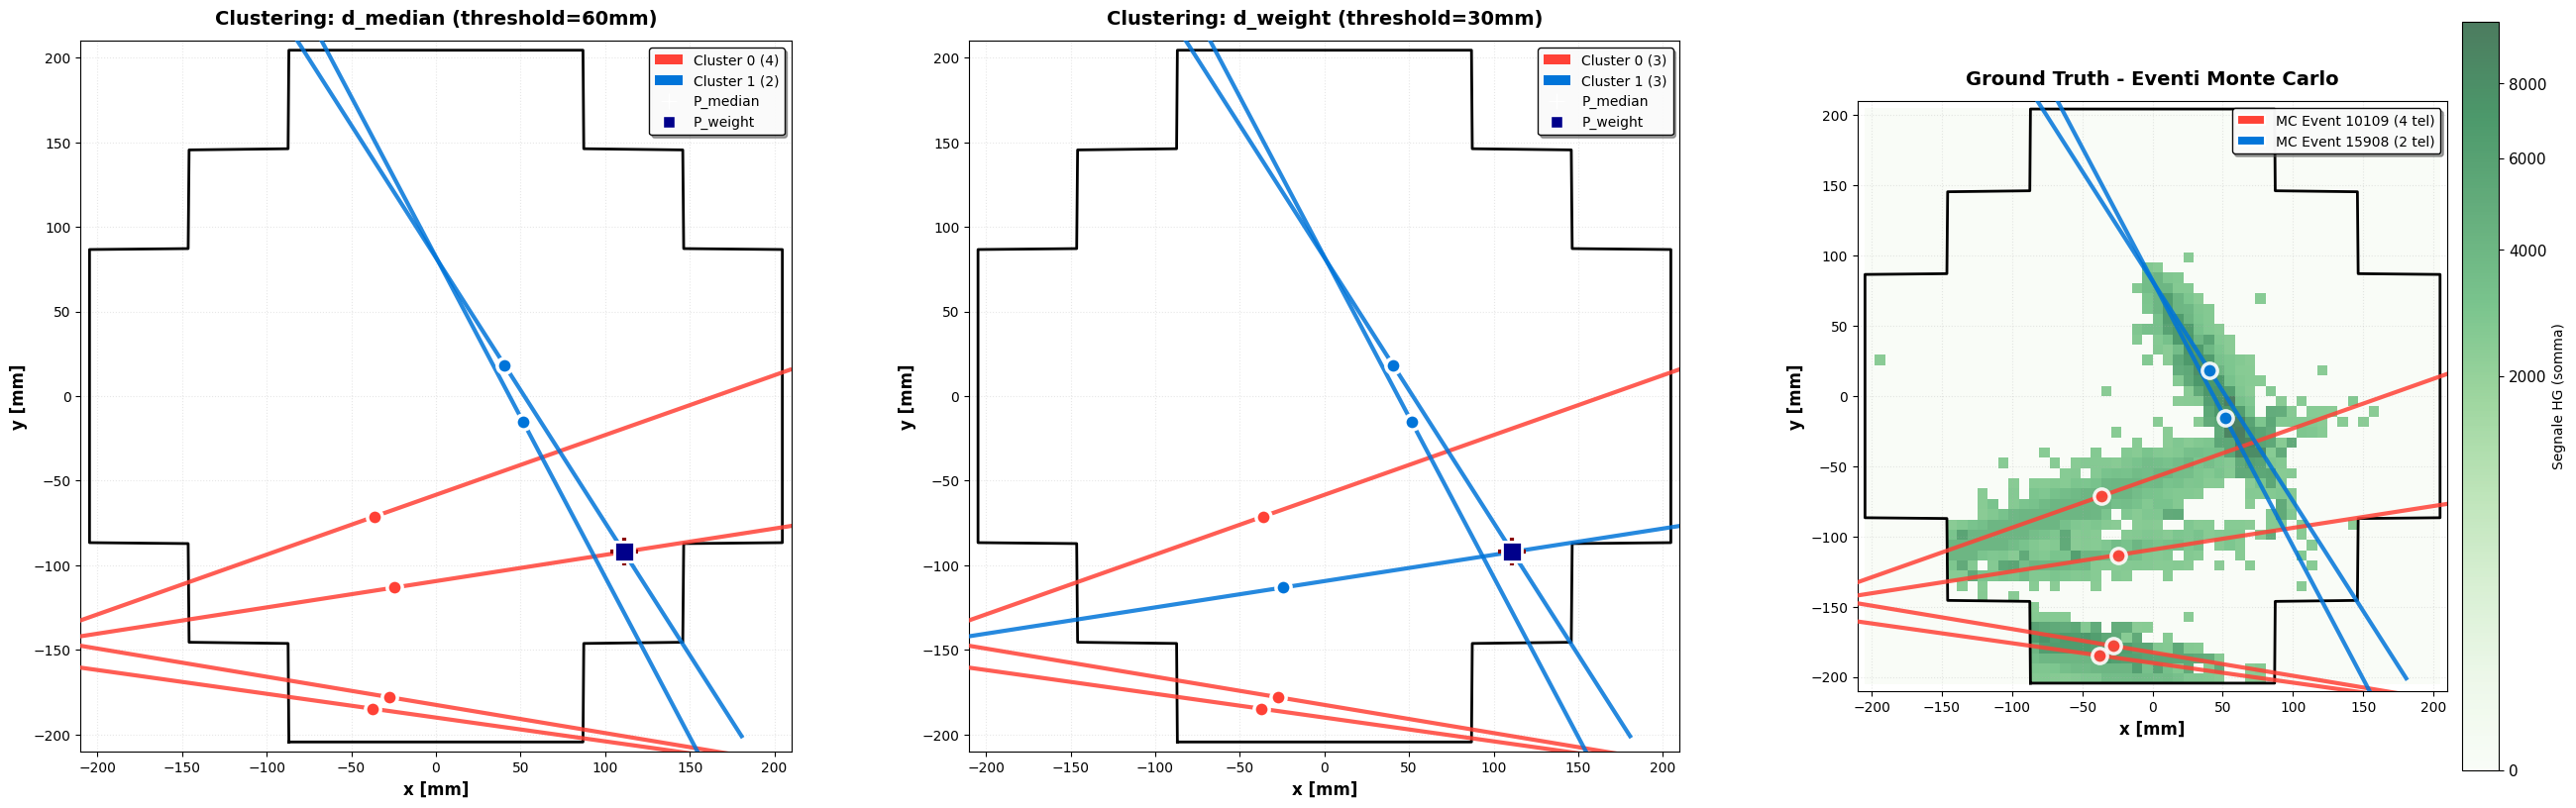

 time_group 4
  Rette totali: 6
  d_median: 6/6 corrette (100.0%)
  d_weight: 3/6 corrette (50.0%)

TIME GROUP 5
Telescopi: 3 | Eventi MC: [15912 24606] | MCRUN: [220000]
Cluster DBSCAN trovati: [0]


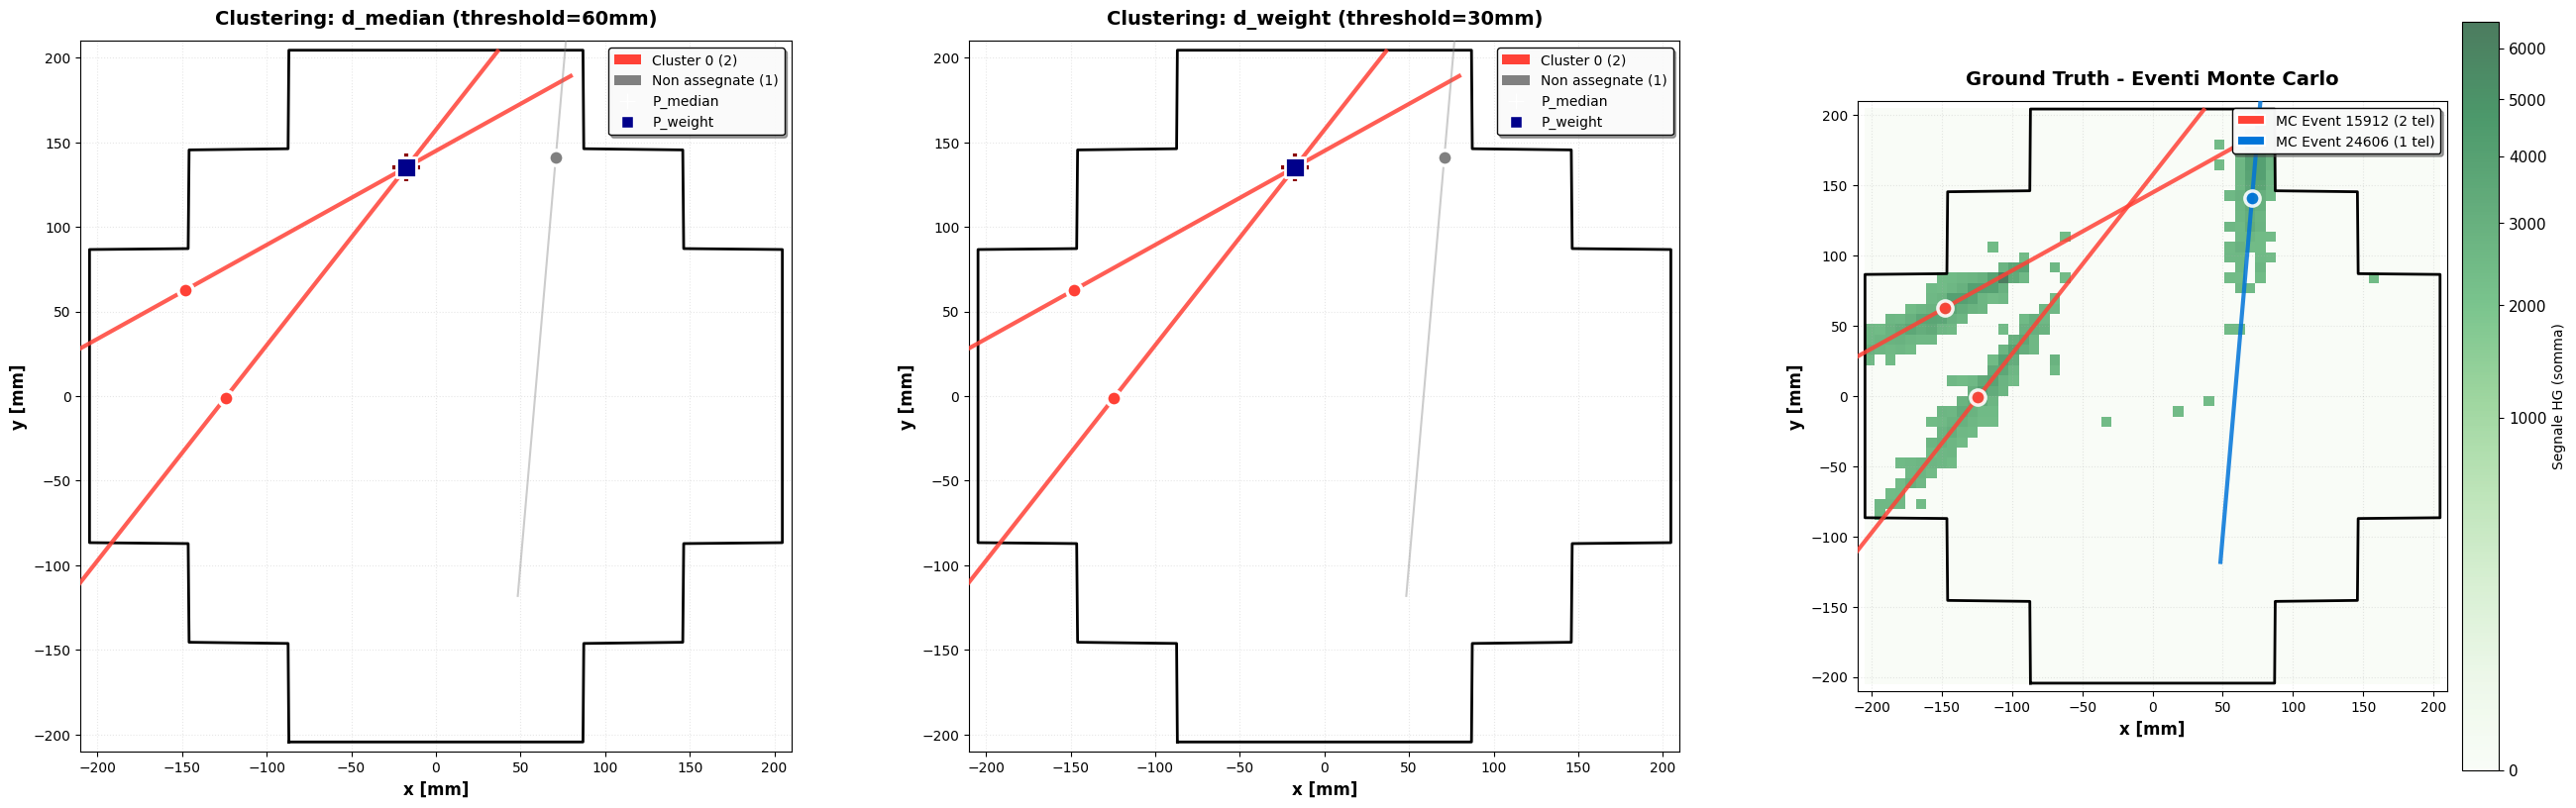

 time_group 5
  Rette totali: 3
  d_median: 3/3 corrette (100.0%)
  d_weight: 3/3 corrette (100.0%)

TIME GROUP 11
Telescopi: 3 | Eventi MC: [38716 43606] | MCRUN: [220000]
 Nessuna intersezione HG per time_group 11, skip.

TIME GROUP 18
Telescopi: 3 | Eventi MC: [8317 9000] | MCRUN: [220001]
Cluster DBSCAN trovati: [0]


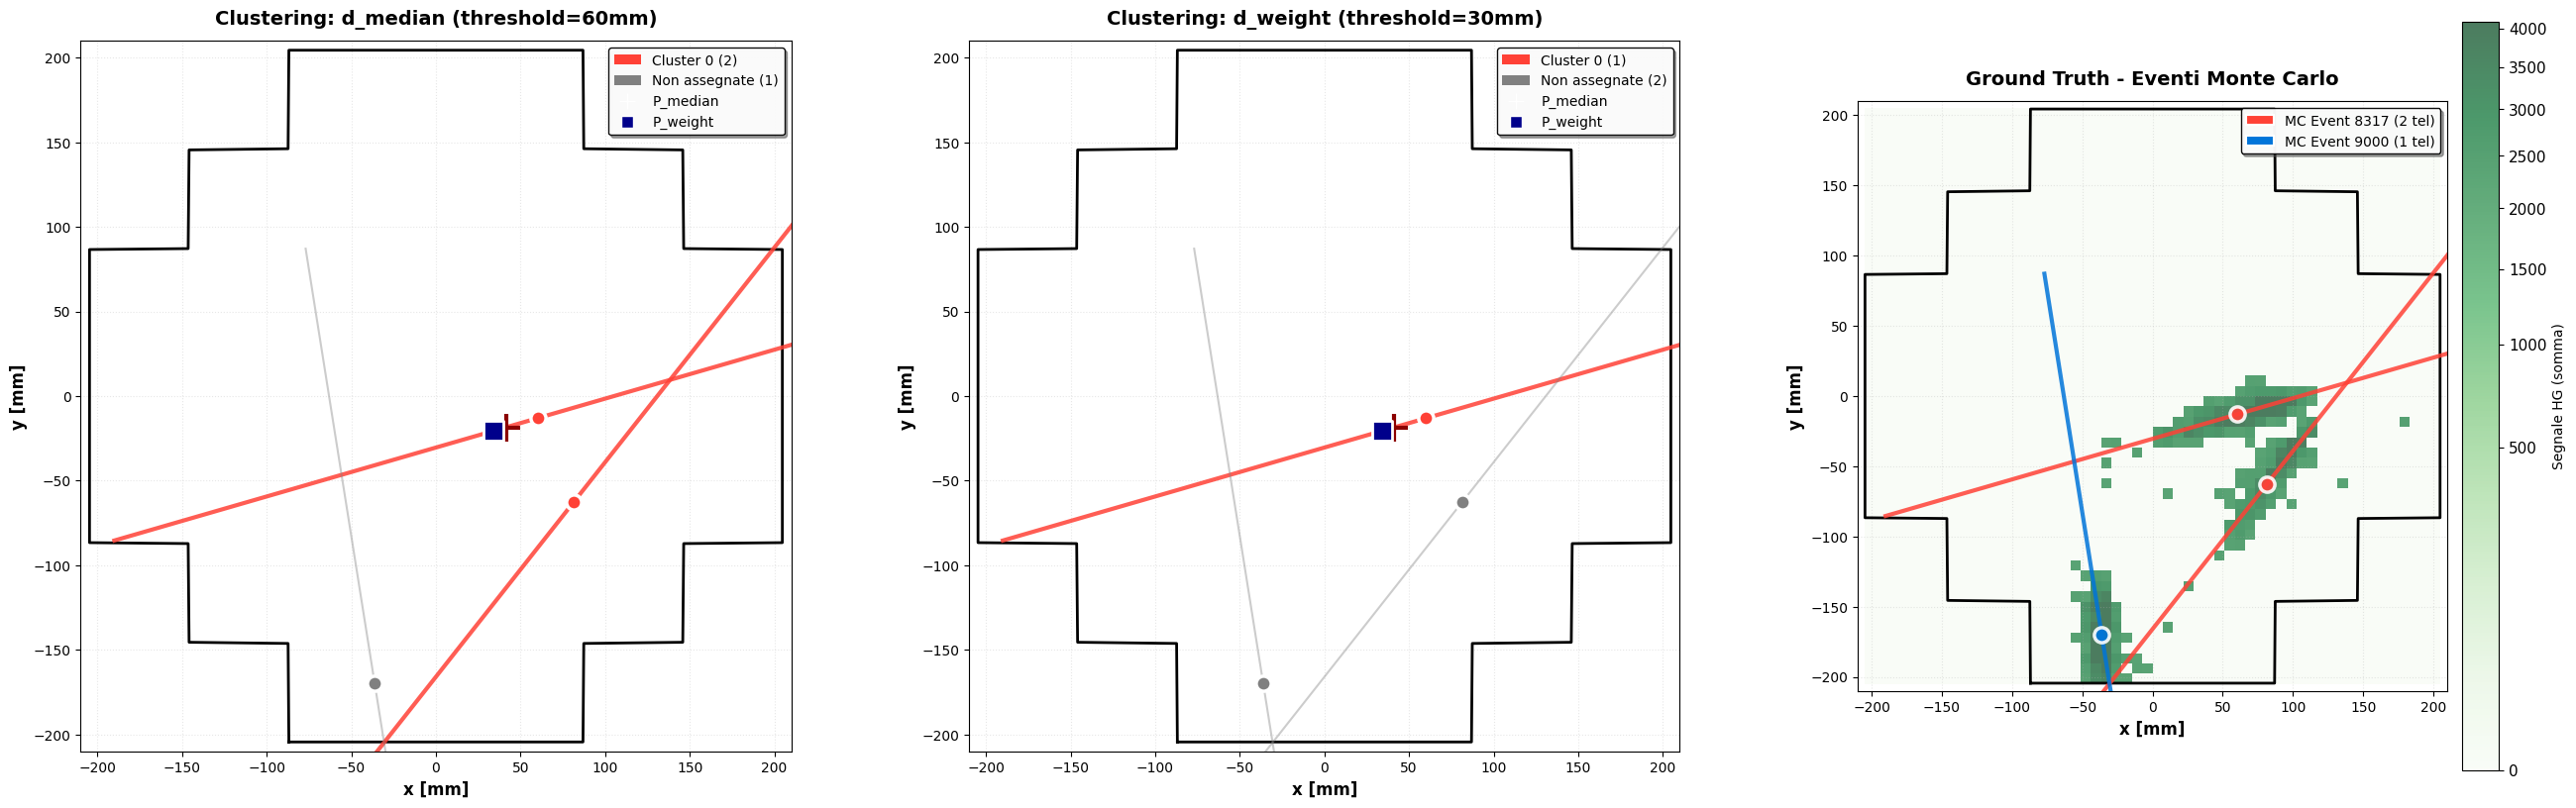

 time_group 18
  Rette totali: 3
  d_median: 3/3 corrette (100.0%)
  d_weight: 2/3 corrette (66.7%)

TIME GROUP 24
Telescopi: 4 | Eventi MC: [44000 44006] | MCRUN: [220001]
Cluster DBSCAN trovati: [0]


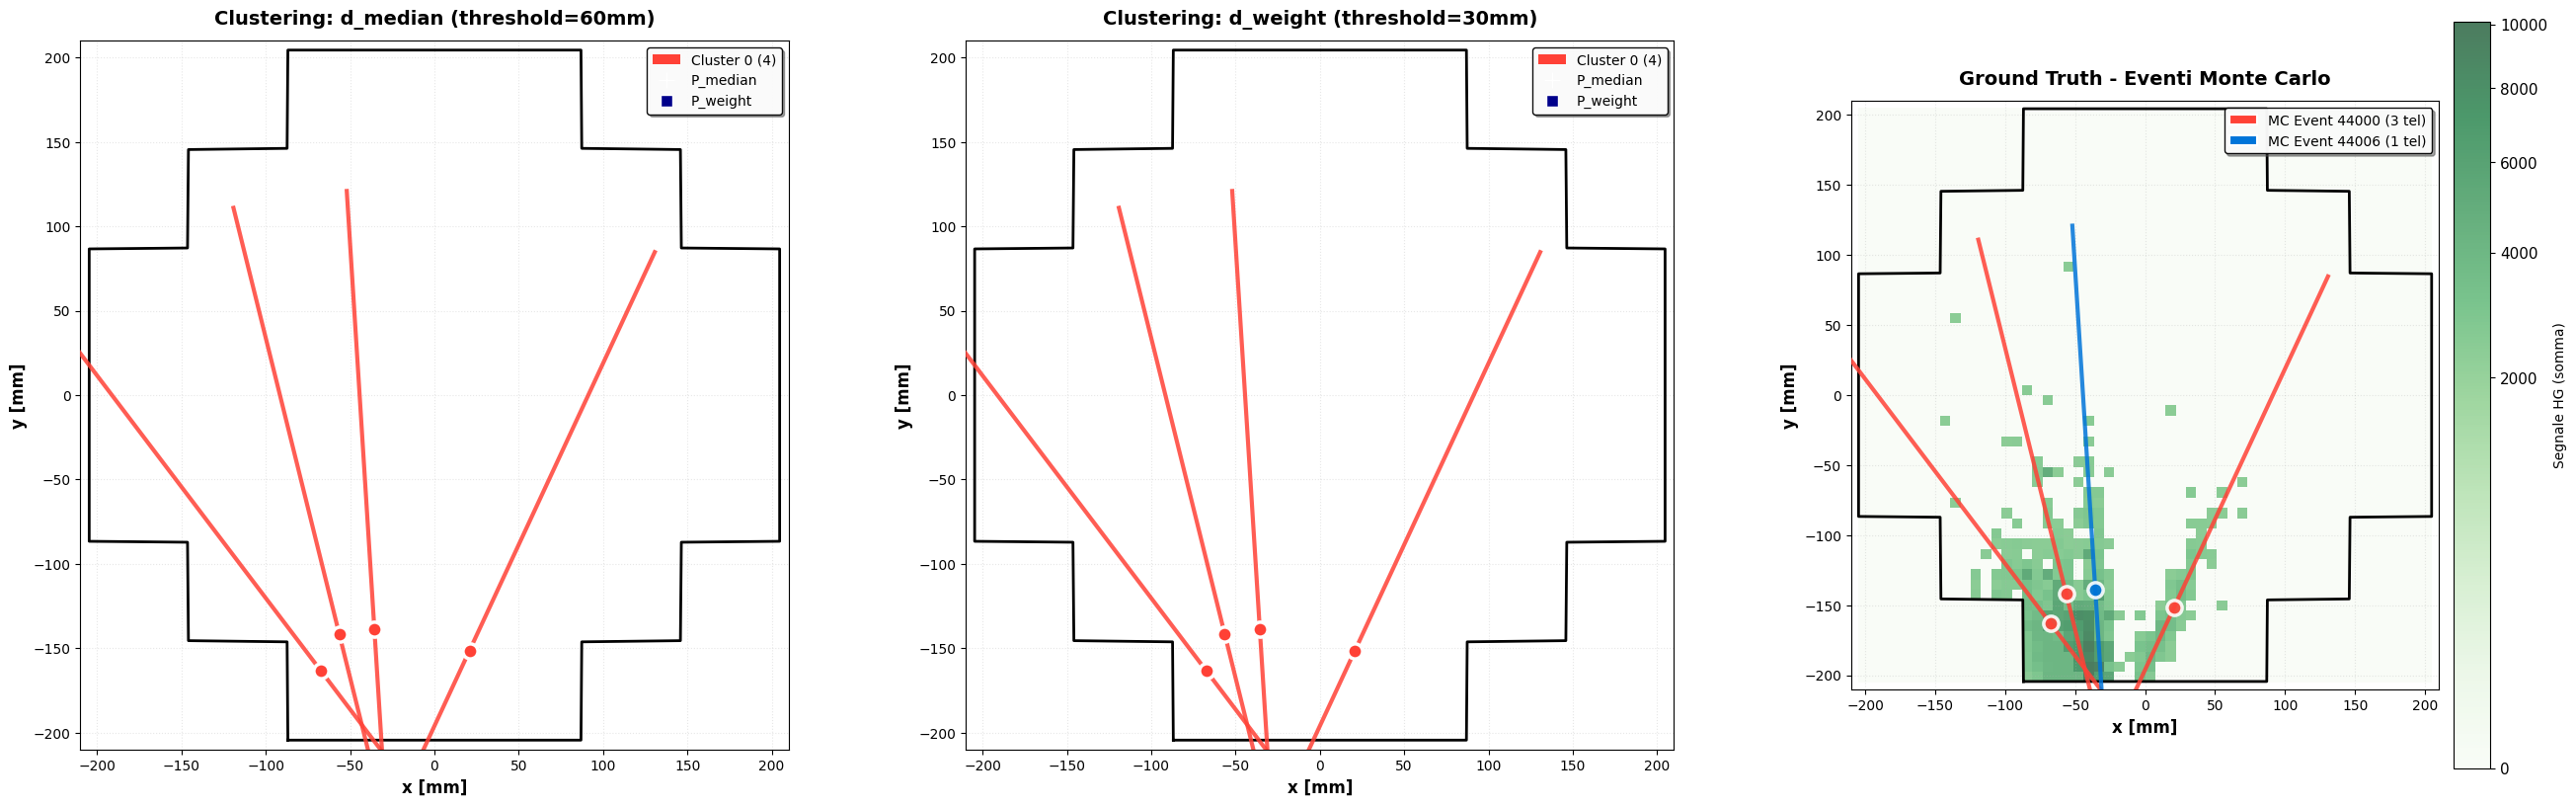

 time_group 24
  Rette totali: 4
  d_median: 0/4 corrette (0.0%)
  d_weight: 0/4 corrette (0.0%)

TIME GROUP 25
Telescopi: 7 | Eventi MC: [44016  7903] | MCRUN: [220001 220002]
Cluster DBSCAN trovati: [0, 1]


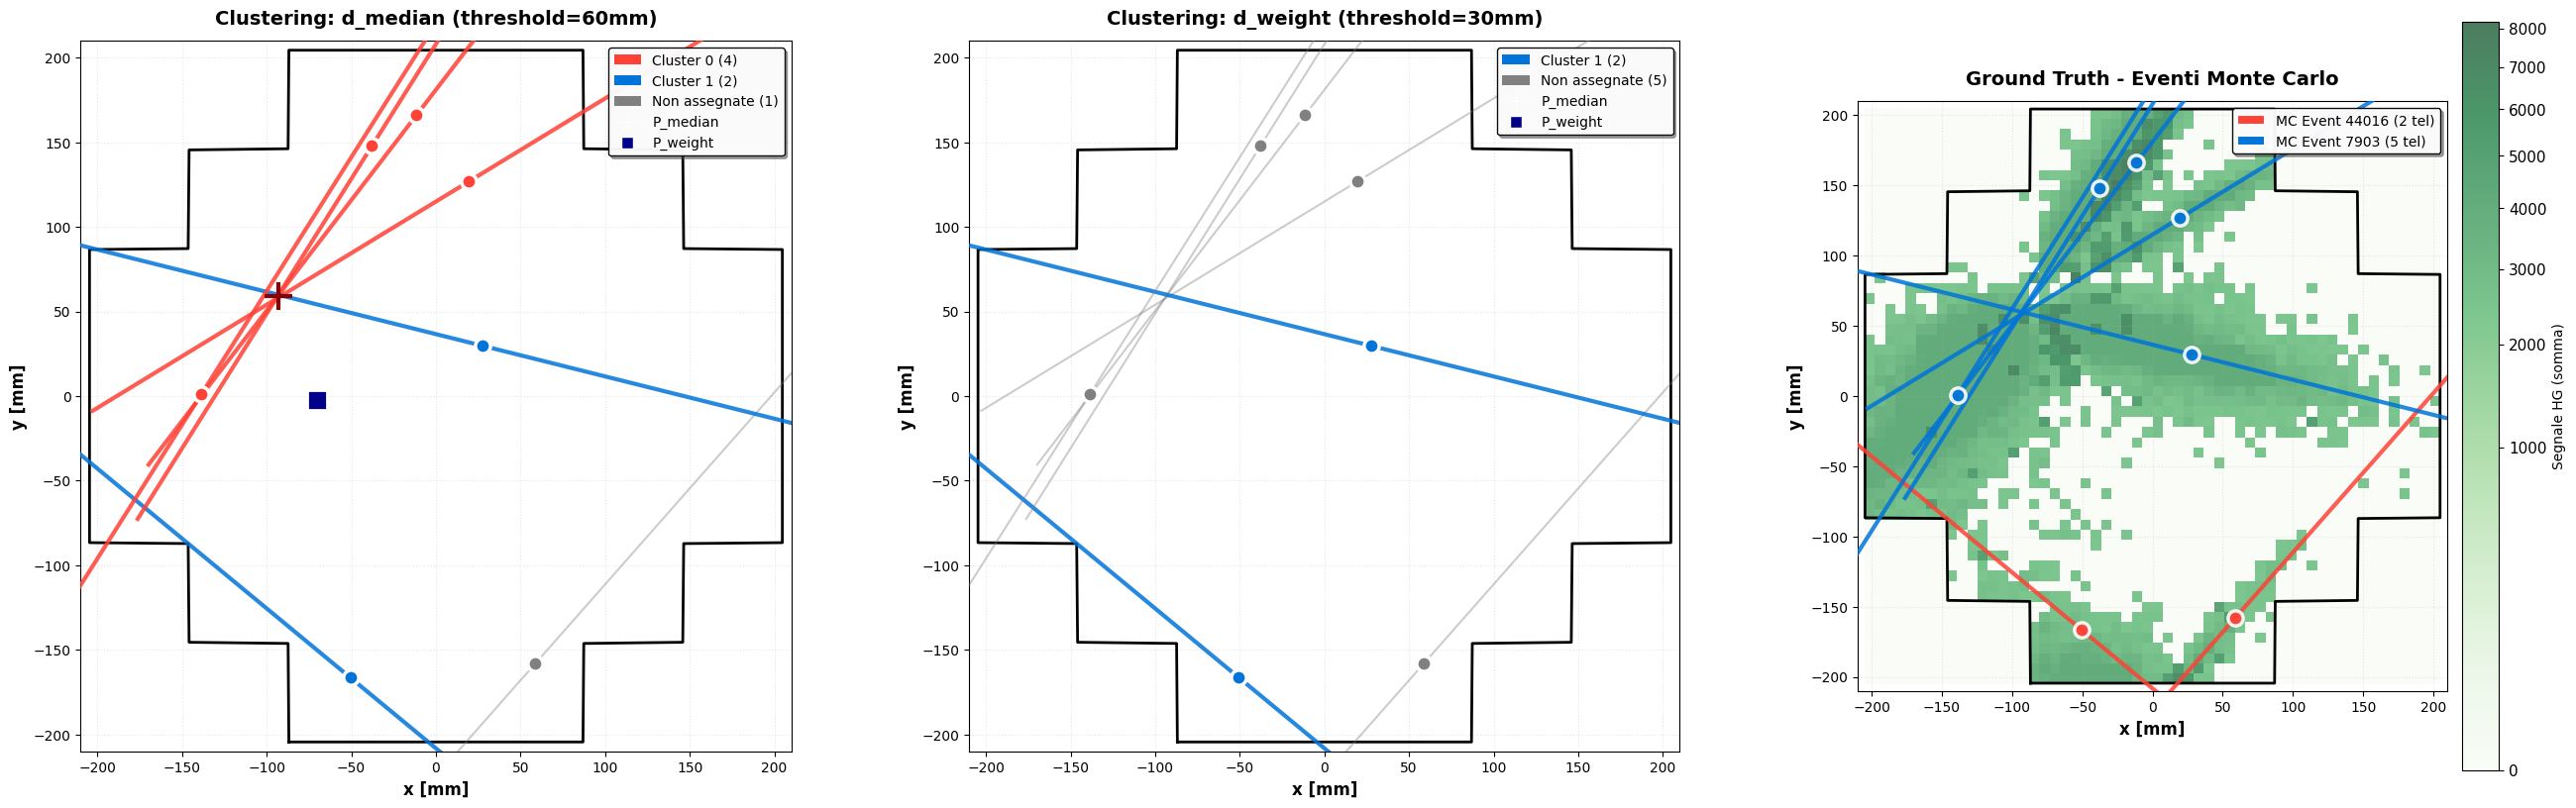

 time_group 25
  Rette totali: 7
  d_median: 4/7 corrette (57.1%)
  d_weight: 0/7 corrette (0.0%)

TIME GROUP 26
Telescopi: 6 | Eventi MC: [ 7919 36113] | MCRUN: [220002]
Cluster DBSCAN trovati: [0]


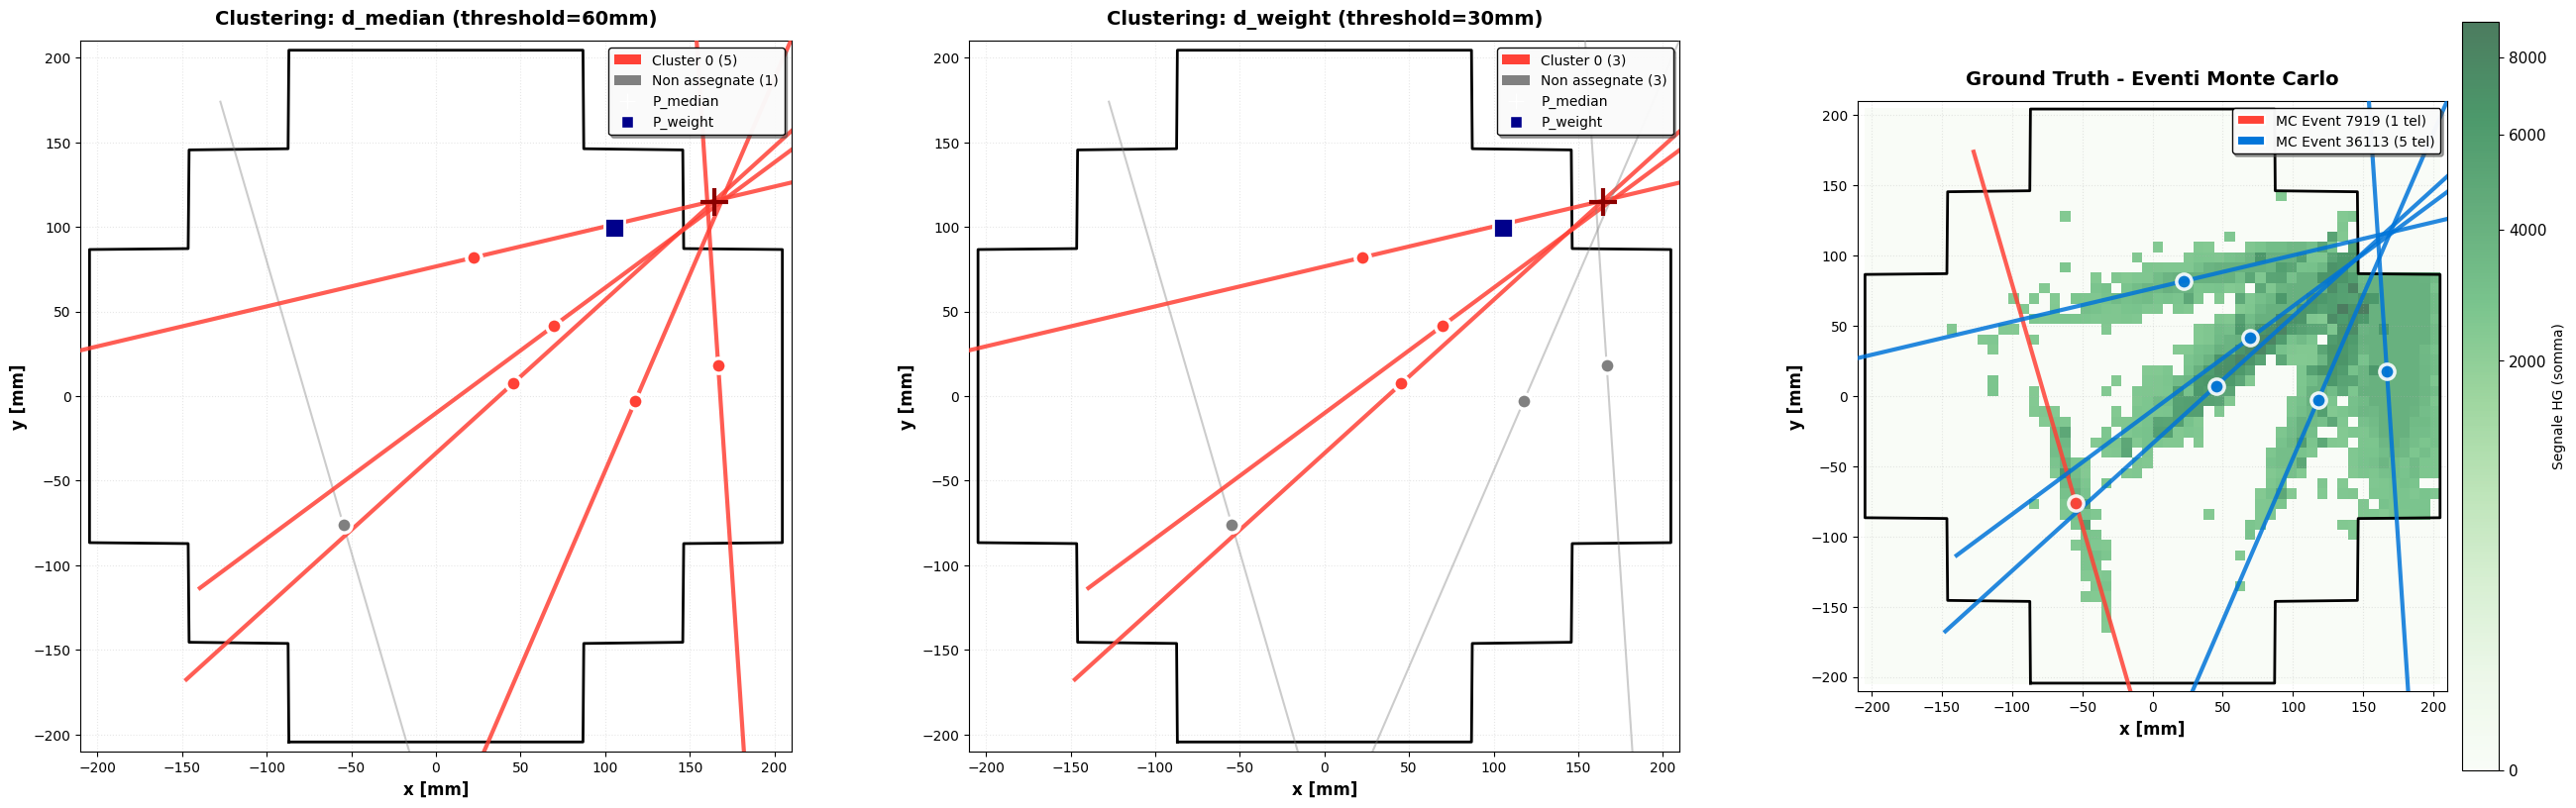

 time_group 26
  Rette totali: 6
  d_median: 6/6 corrette (100.0%)
  d_weight: 4/6 corrette (66.7%)

TIME GROUP 31
Telescopi: 3 | Eventi MC: [ 9500 10403] | MCRUN: [220004]
 Nessuna intersezione HG per time_group 31, skip.

TIME GROUP 32
Telescopi: 4 | Eventi MC: [12604 18008] | MCRUN: [220004]
Cluster DBSCAN trovati: [0]


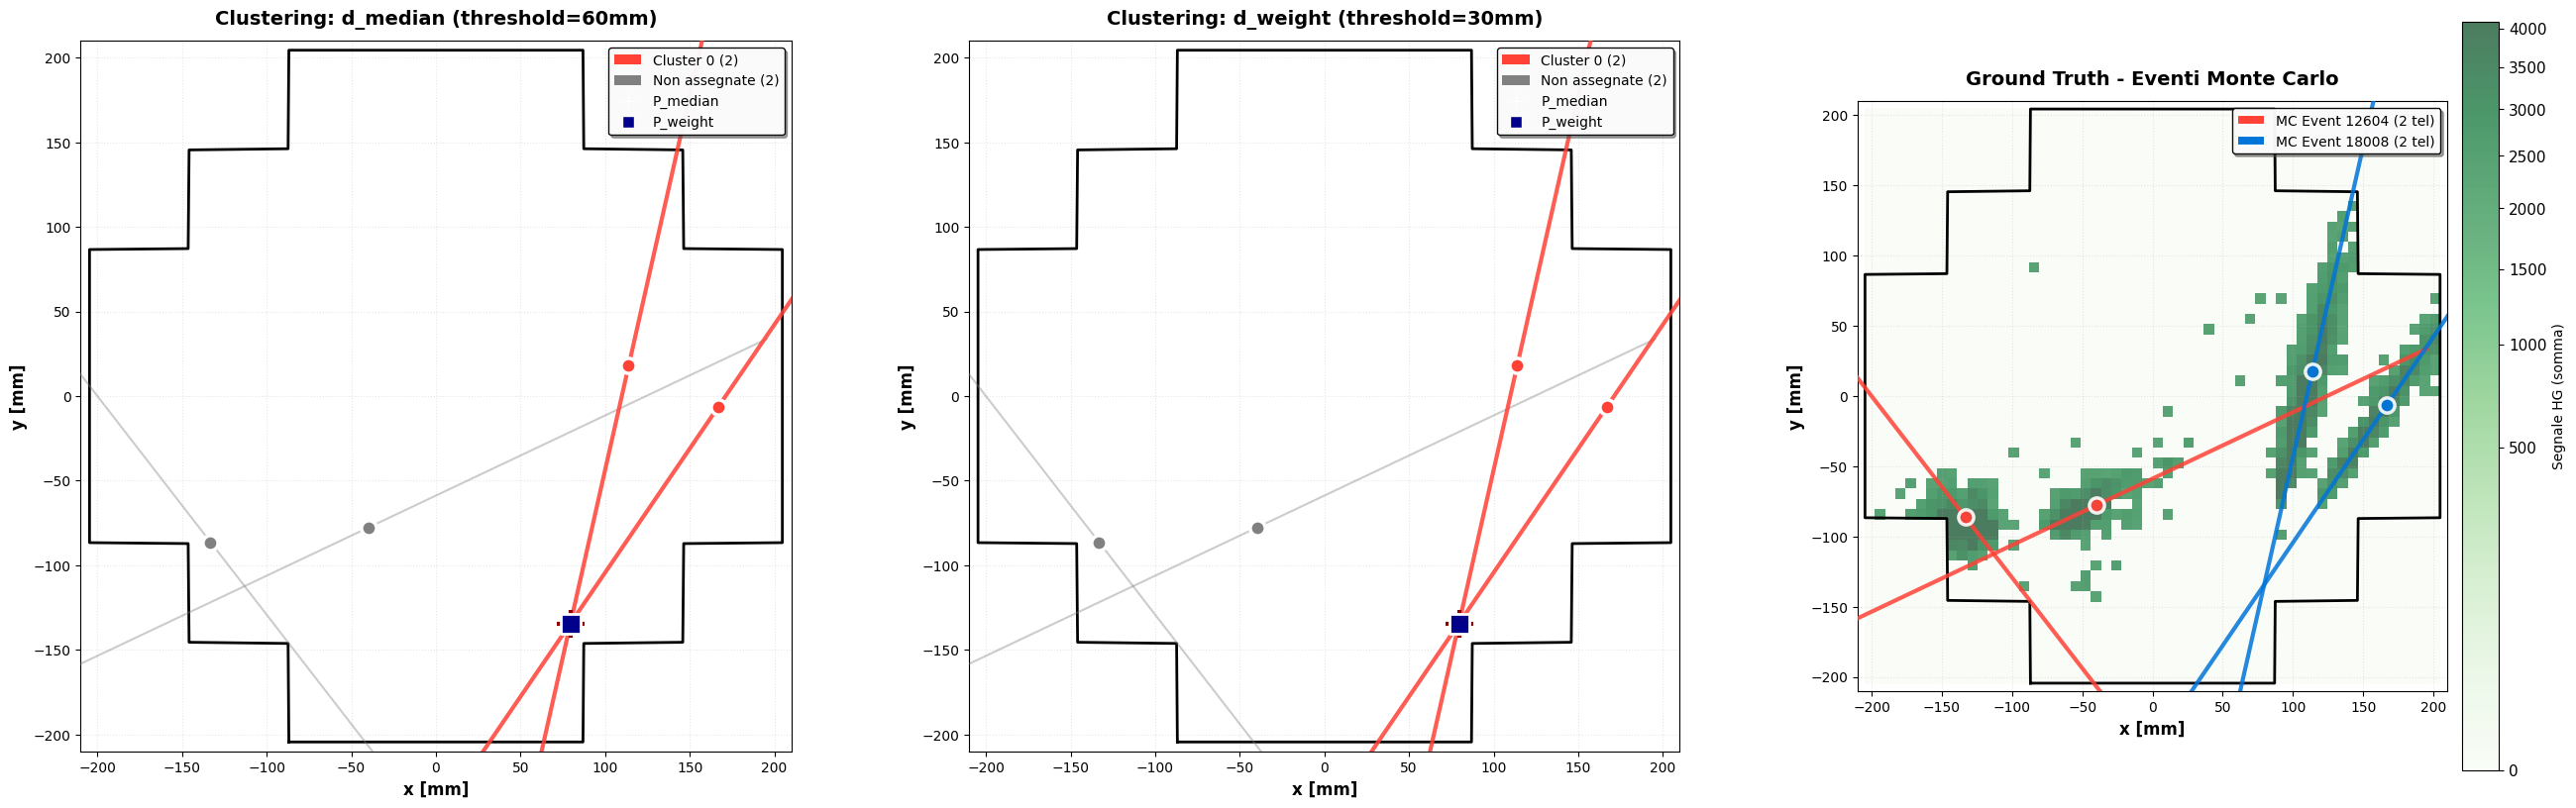

 time_group 32
  Rette totali: 4
  d_median: 2/4 corrette (50.0%)
  d_weight: 2/4 corrette (50.0%)

TIME GROUP 35
Telescopi: 3 | Eventi MC: [15105 15109] | MCRUN: [220005]
Cluster DBSCAN trovati: [0]


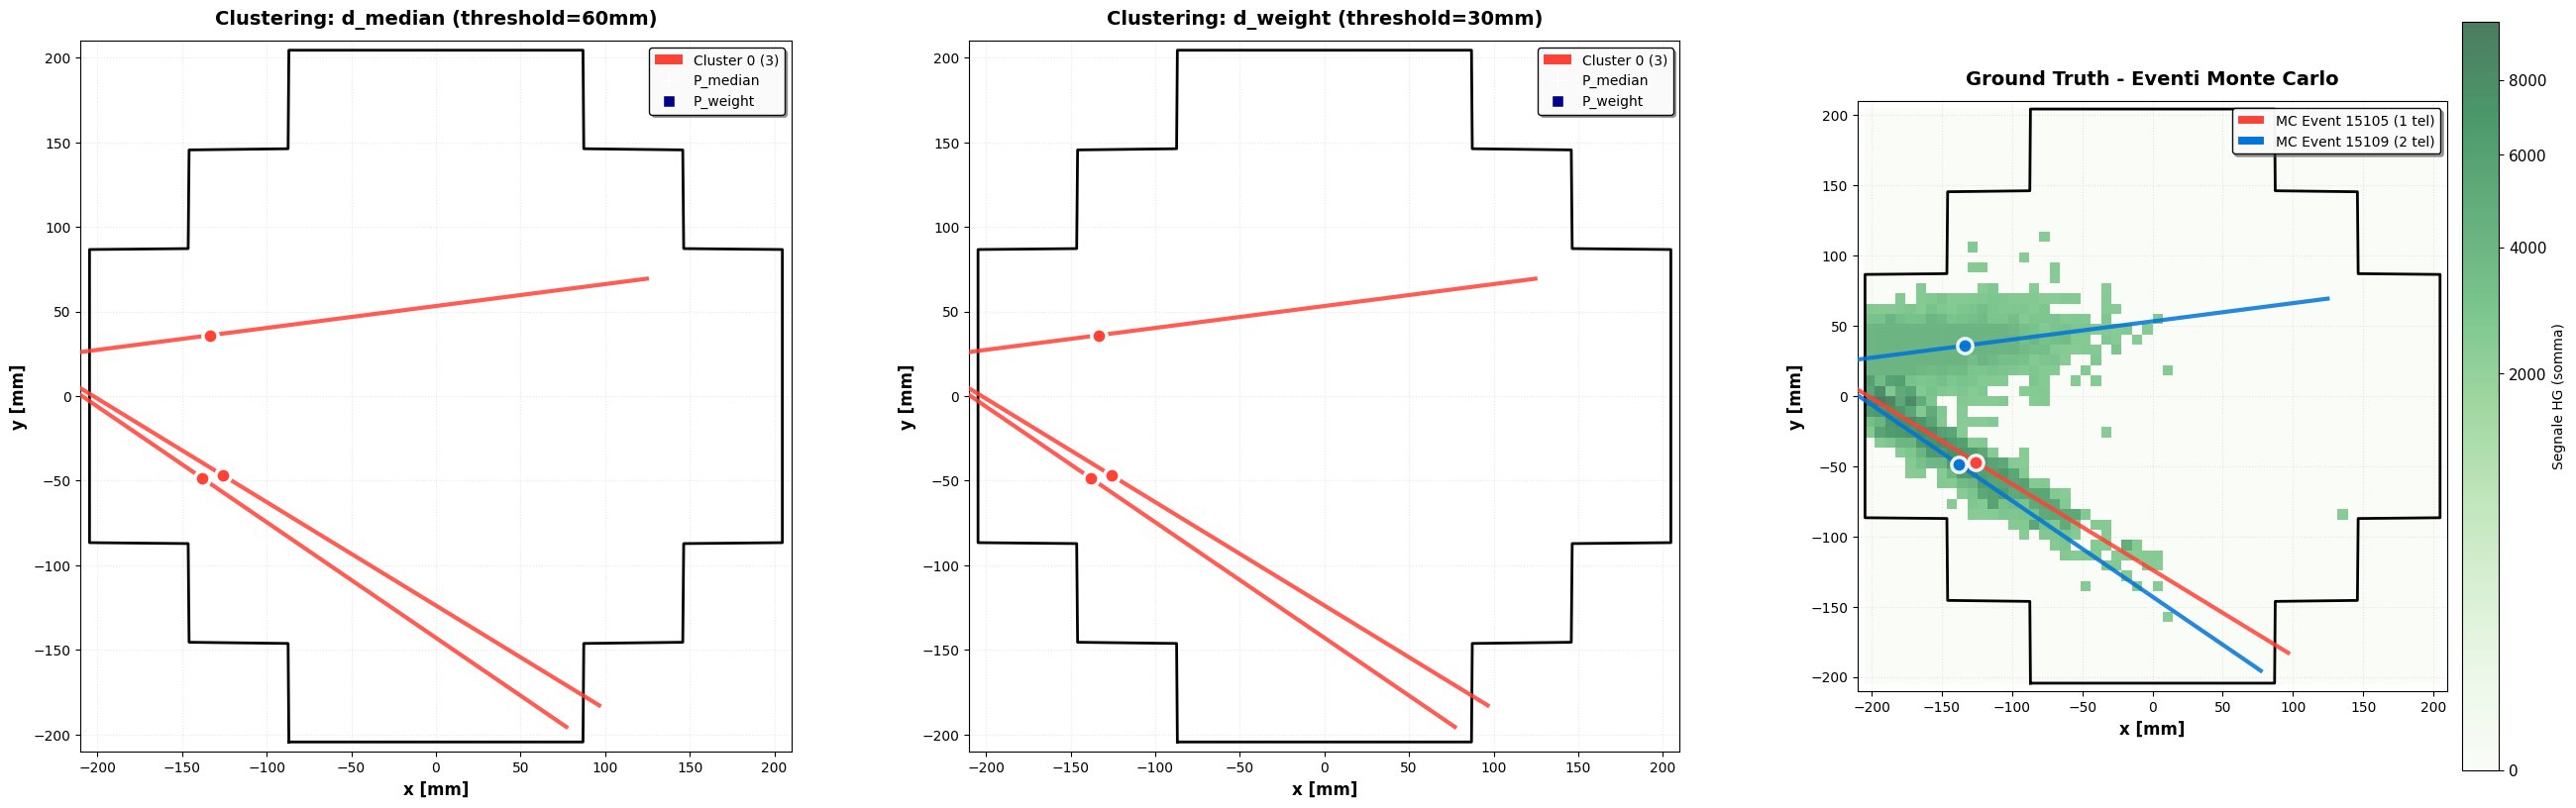

 time_group 35
  Rette totali: 3
  d_median: 0/3 corrette (0.0%)
  d_weight: 0/3 corrette (0.0%)

TIME GROUP 36
Telescopi: 5 | Eventi MC: [15116 22204] | MCRUN: [220005]
Cluster DBSCAN trovati: [0]


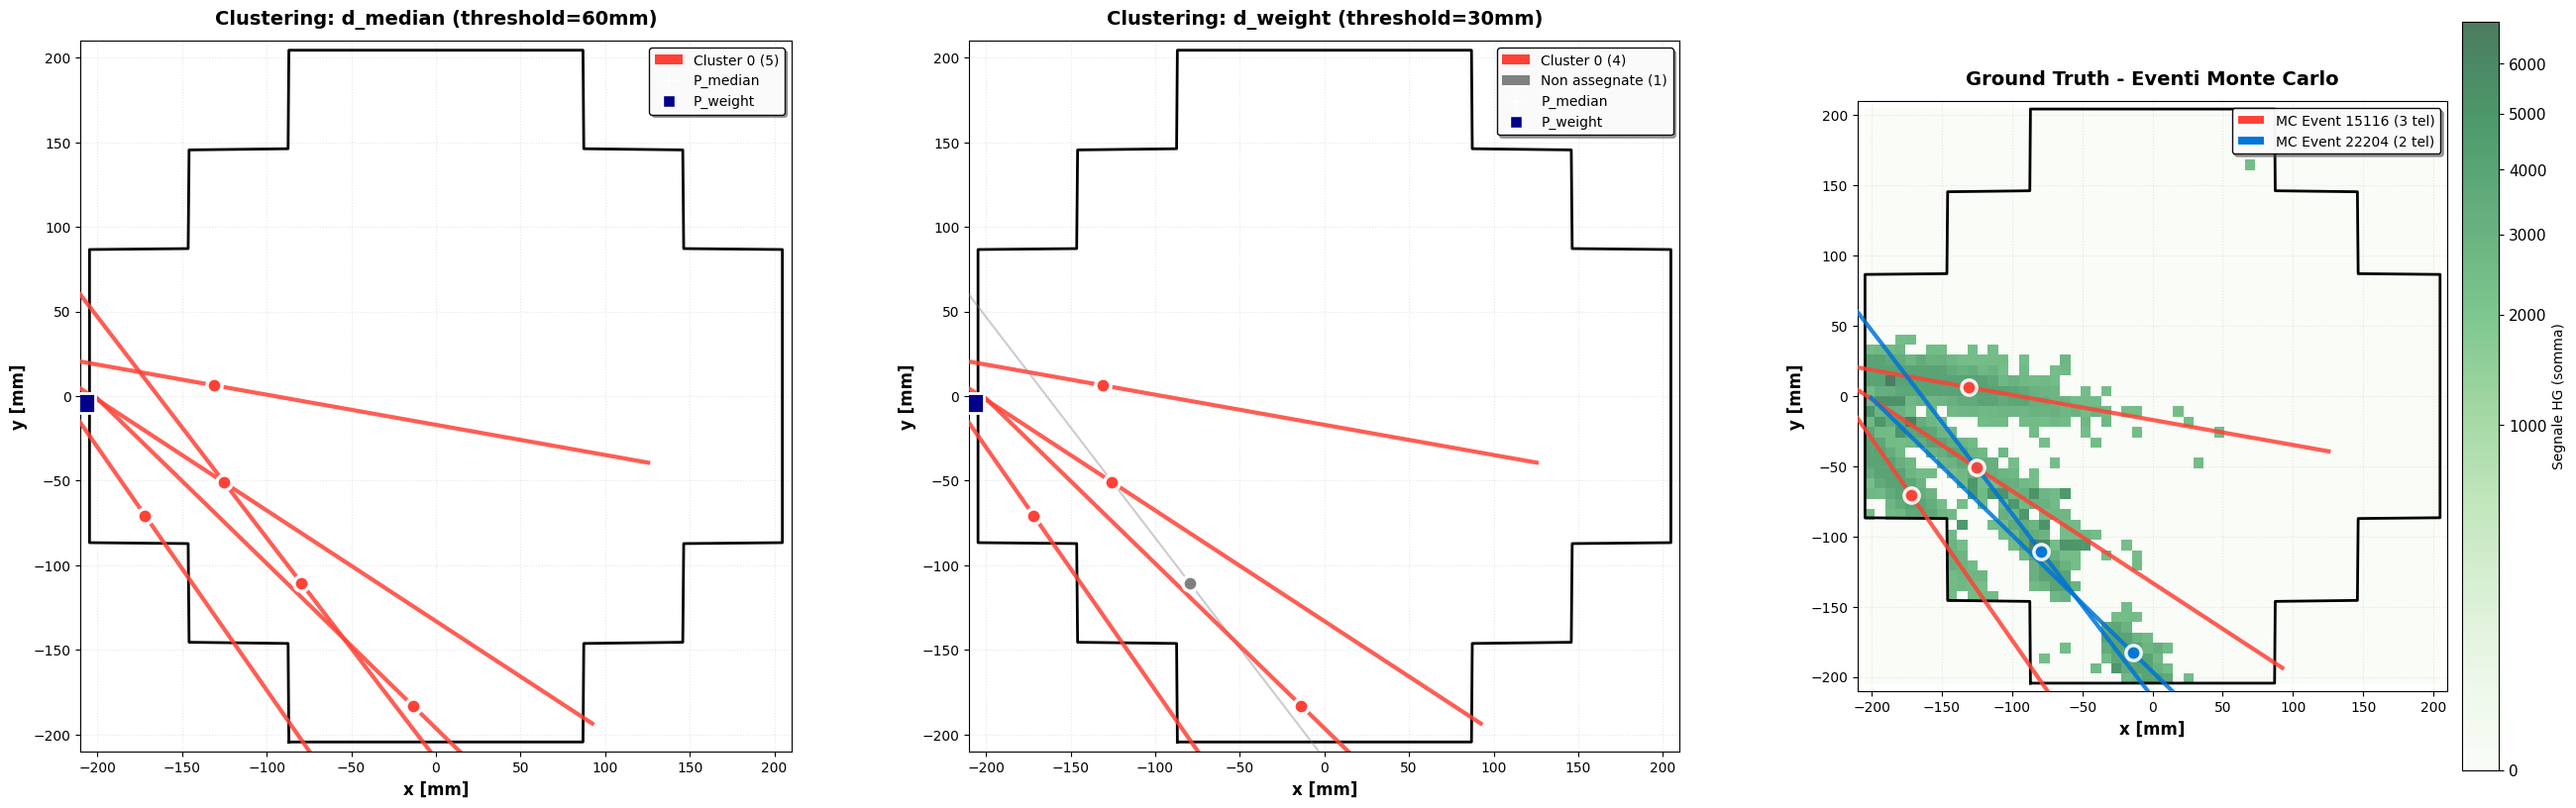

 time_group 36
  Rette totali: 5
  d_median: 0/5 corrette (0.0%)
  d_weight: 0/5 corrette (0.0%)

TIME GROUP 39
Telescopi: 3 | Eventi MC: [45401 47800] | MCRUN: [220005]
Cluster DBSCAN trovati: [0]


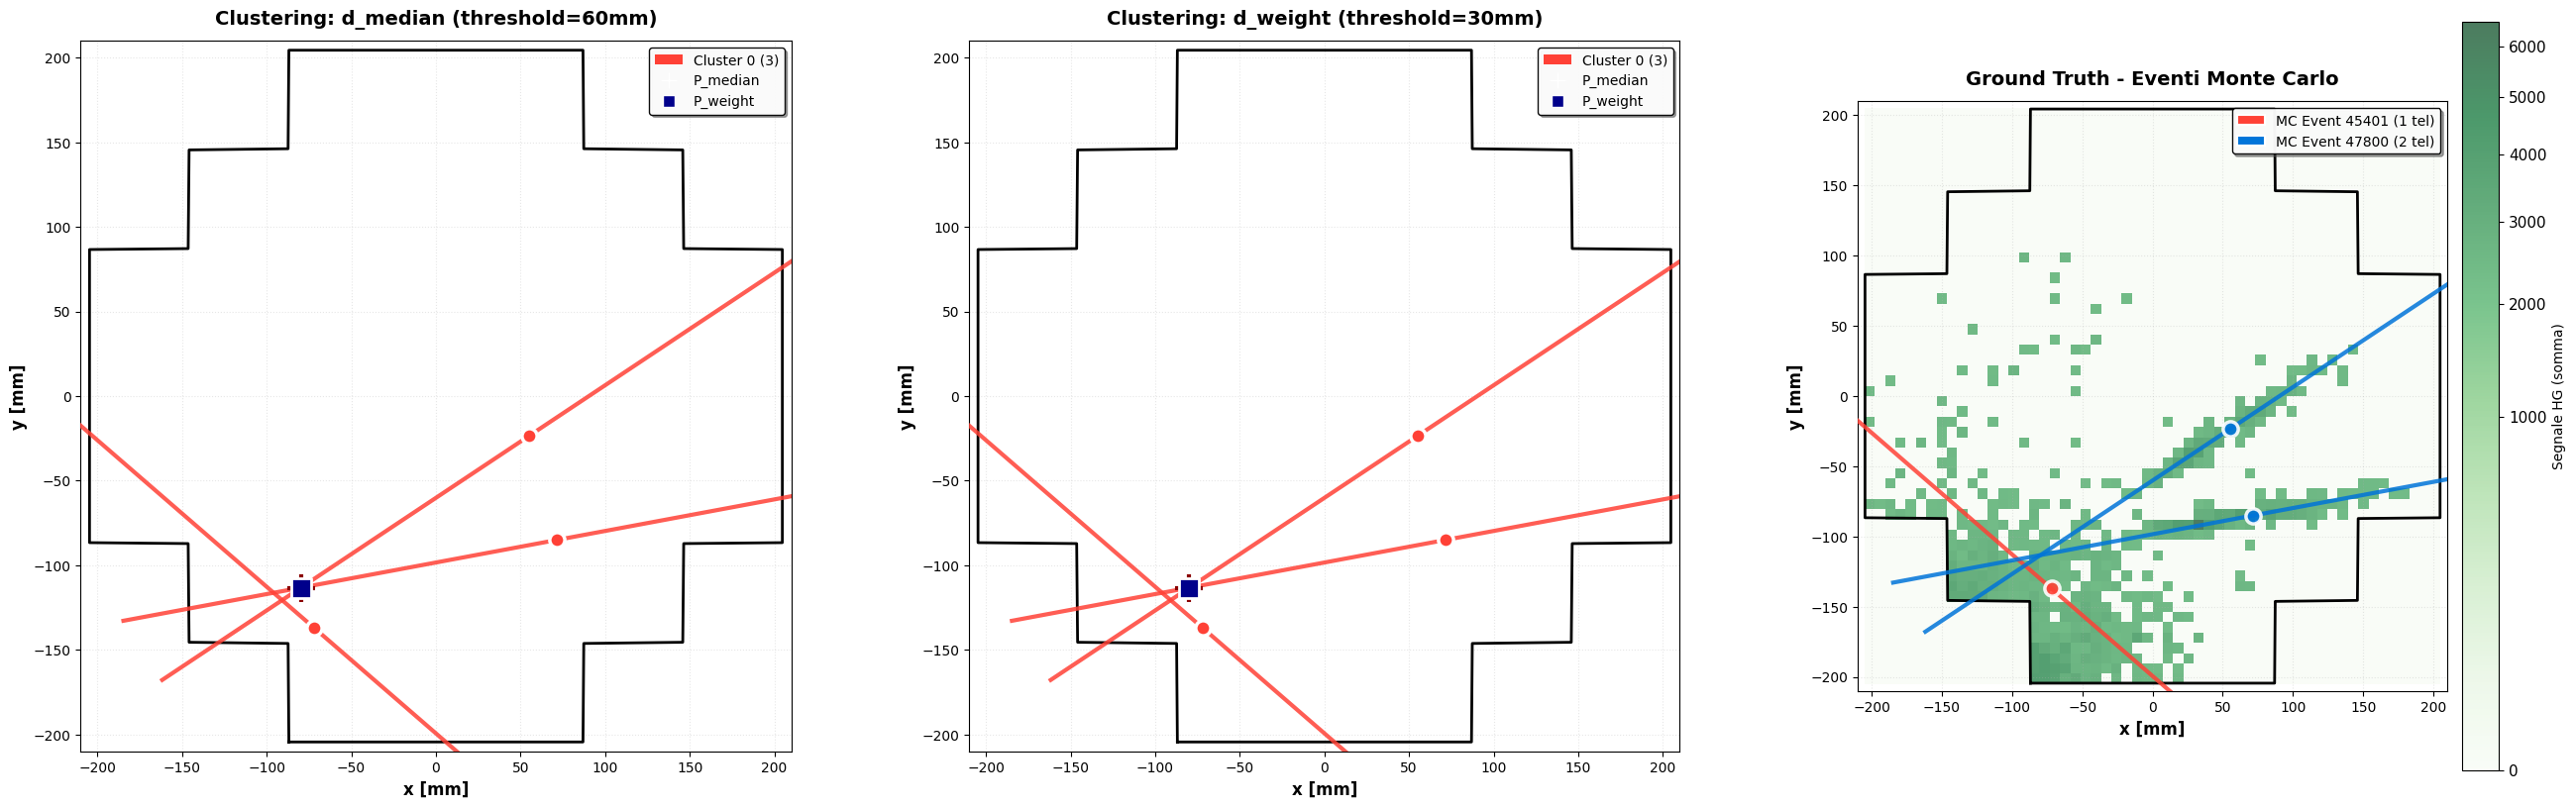

 time_group 39
  Rette totali: 3
  d_median: 0/3 corrette (0.0%)
  d_weight: 0/3 corrette (0.0%)

TIME GROUP 43
Telescopi: 3 | Eventi MC: [33009 34401] | MCRUN: [220006]
Cluster DBSCAN trovati: [0]


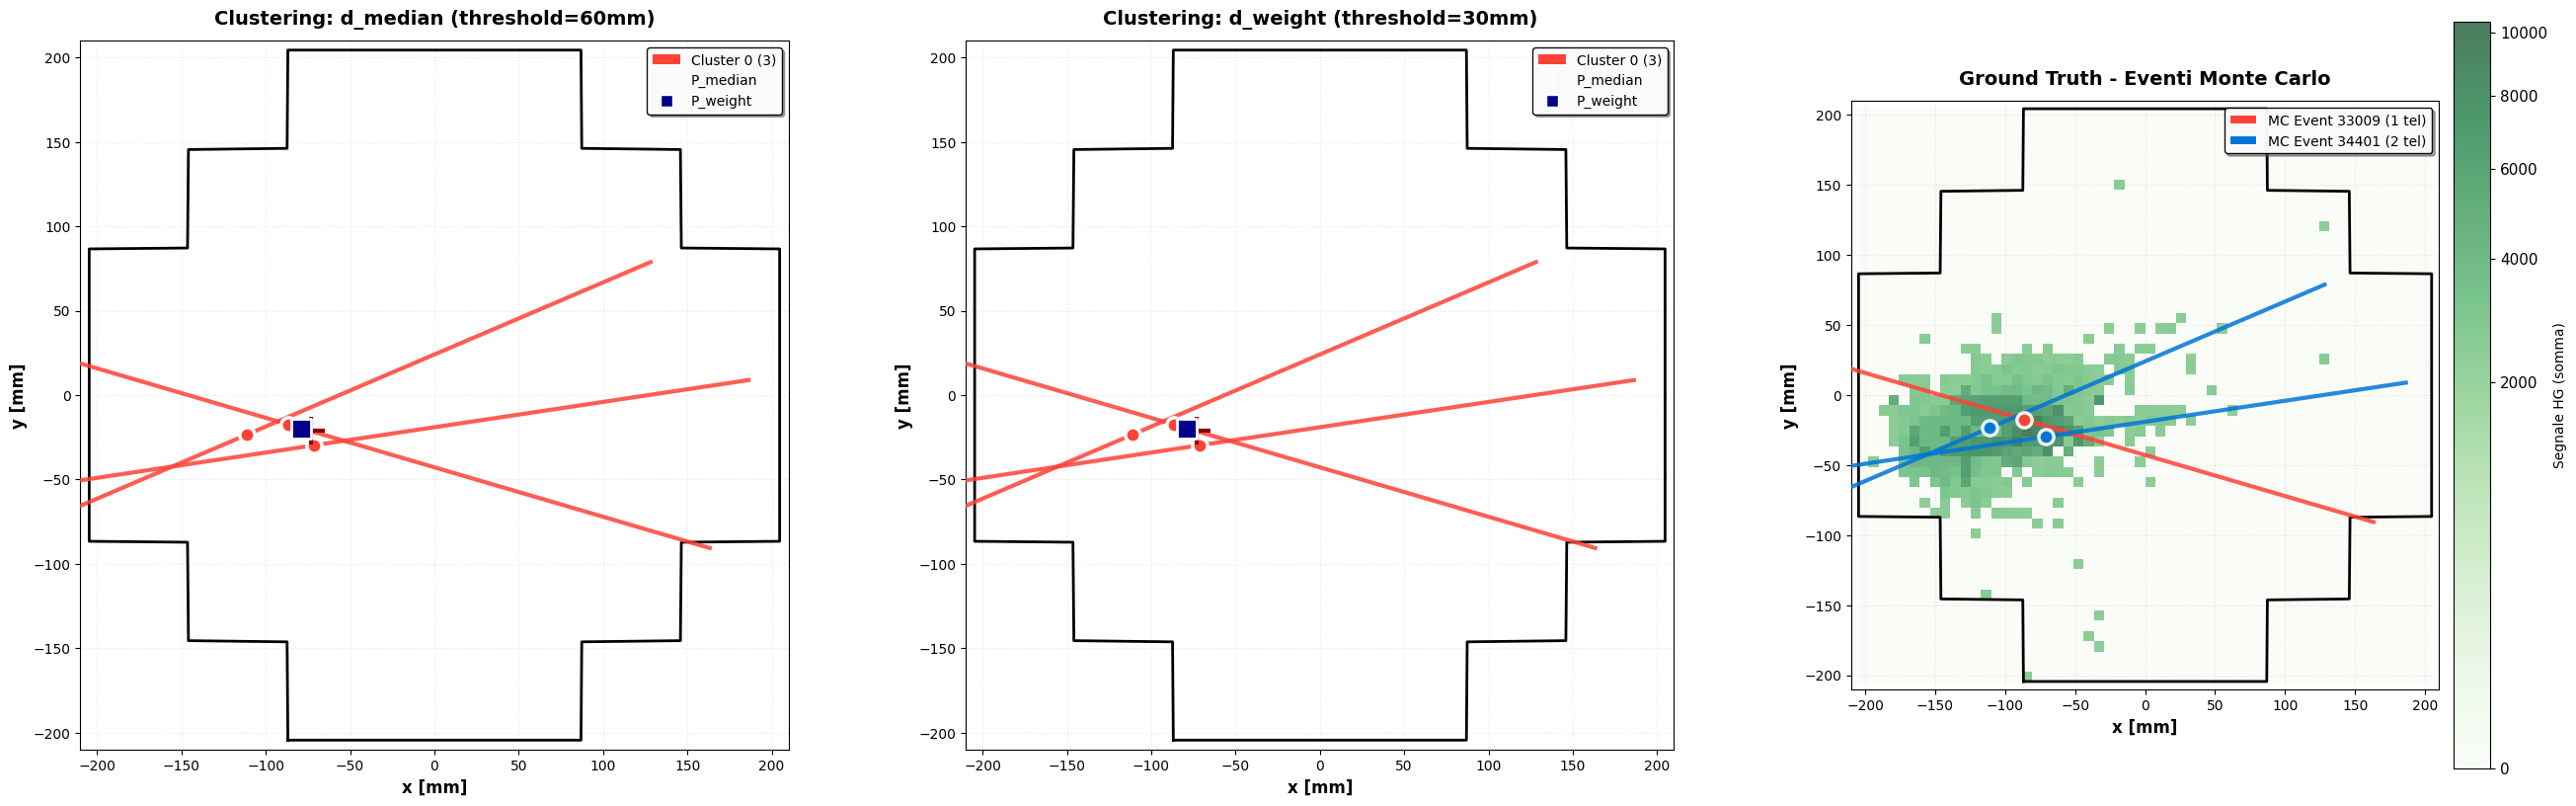

 time_group 43
  Rette totali: 3
  d_median: 0/3 corrette (0.0%)
  d_weight: 0/3 corrette (0.0%)

TIME GROUP 44
Telescopi: 6 | Eventi MC: [34405 34408] | MCRUN: [220006]
Cluster DBSCAN trovati: [0]


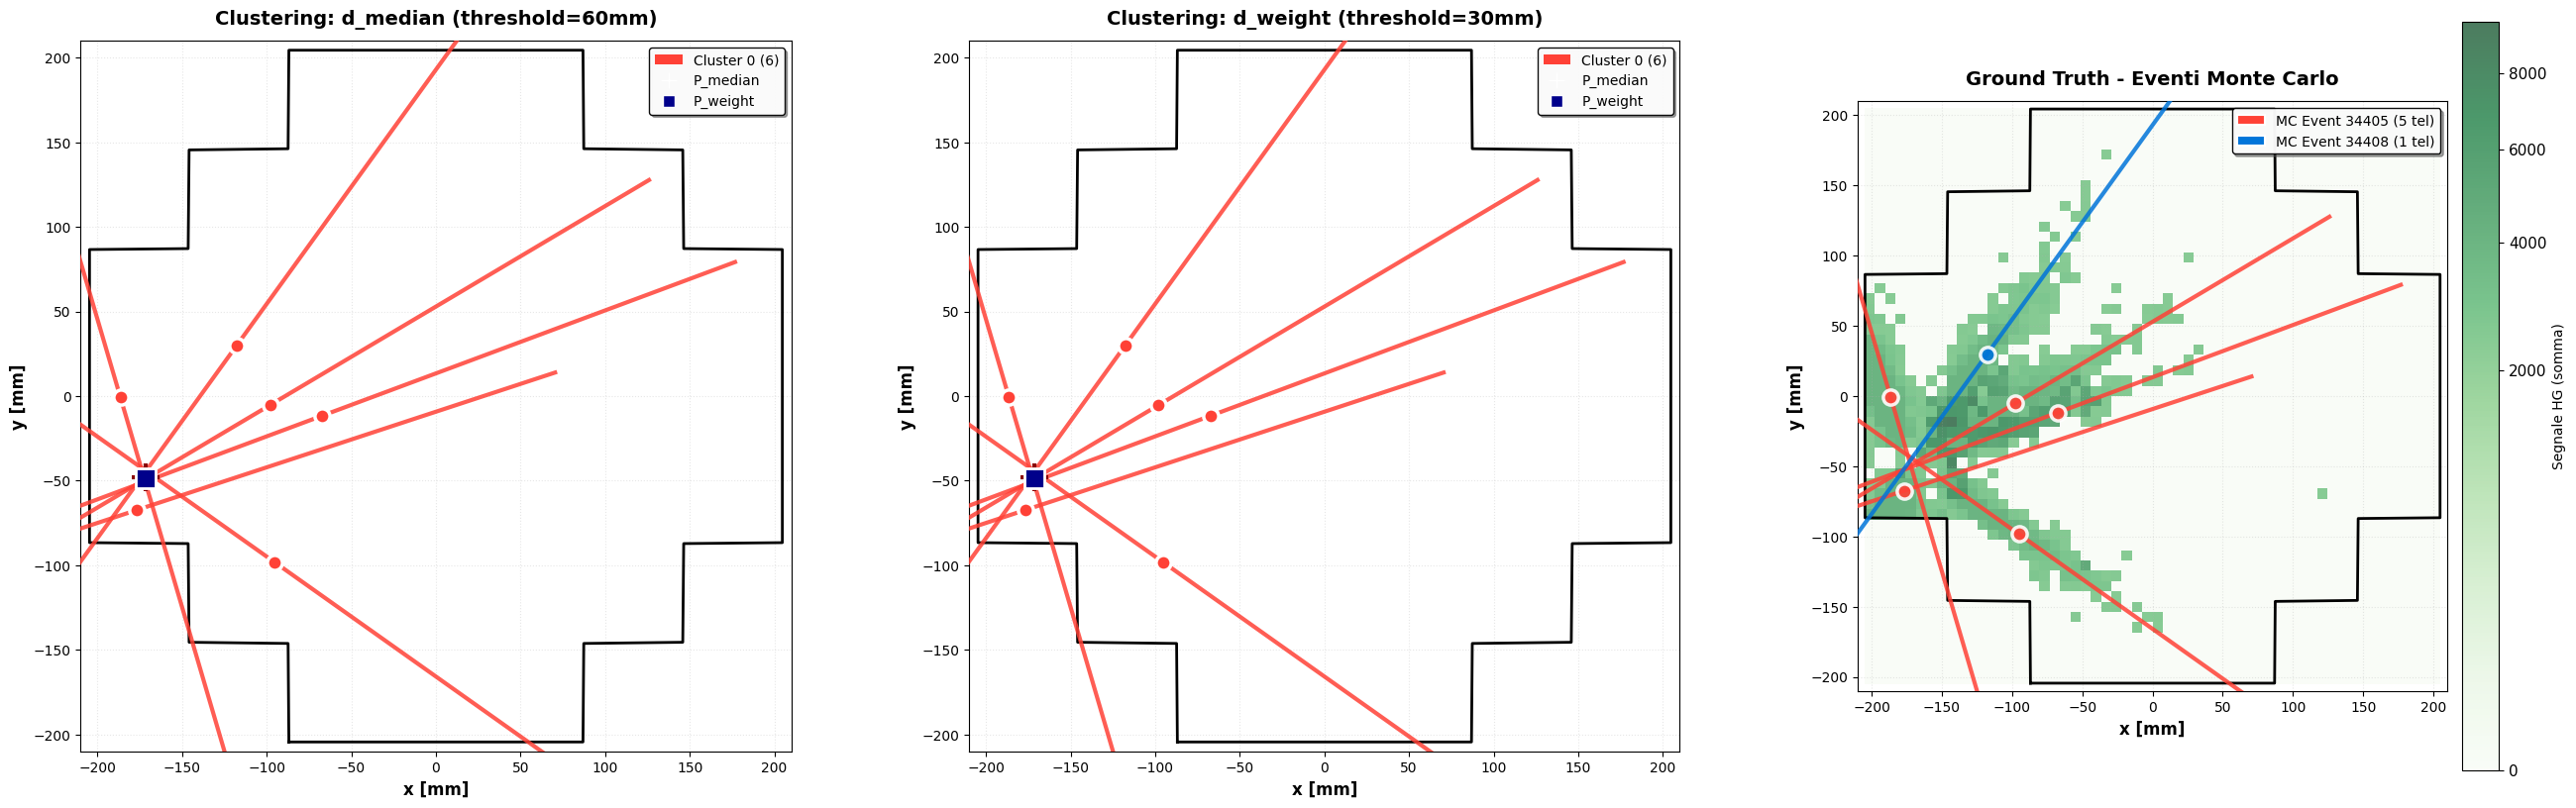

 time_group 44
  Rette totali: 6
  d_median: 0/6 corrette (0.0%)
  d_weight: 0/6 corrette (0.0%)

TIME GROUP 45
Telescopi: 3 | Eventi MC: [37500 43015] | MCRUN: [220006]
Cluster DBSCAN trovati: [0]


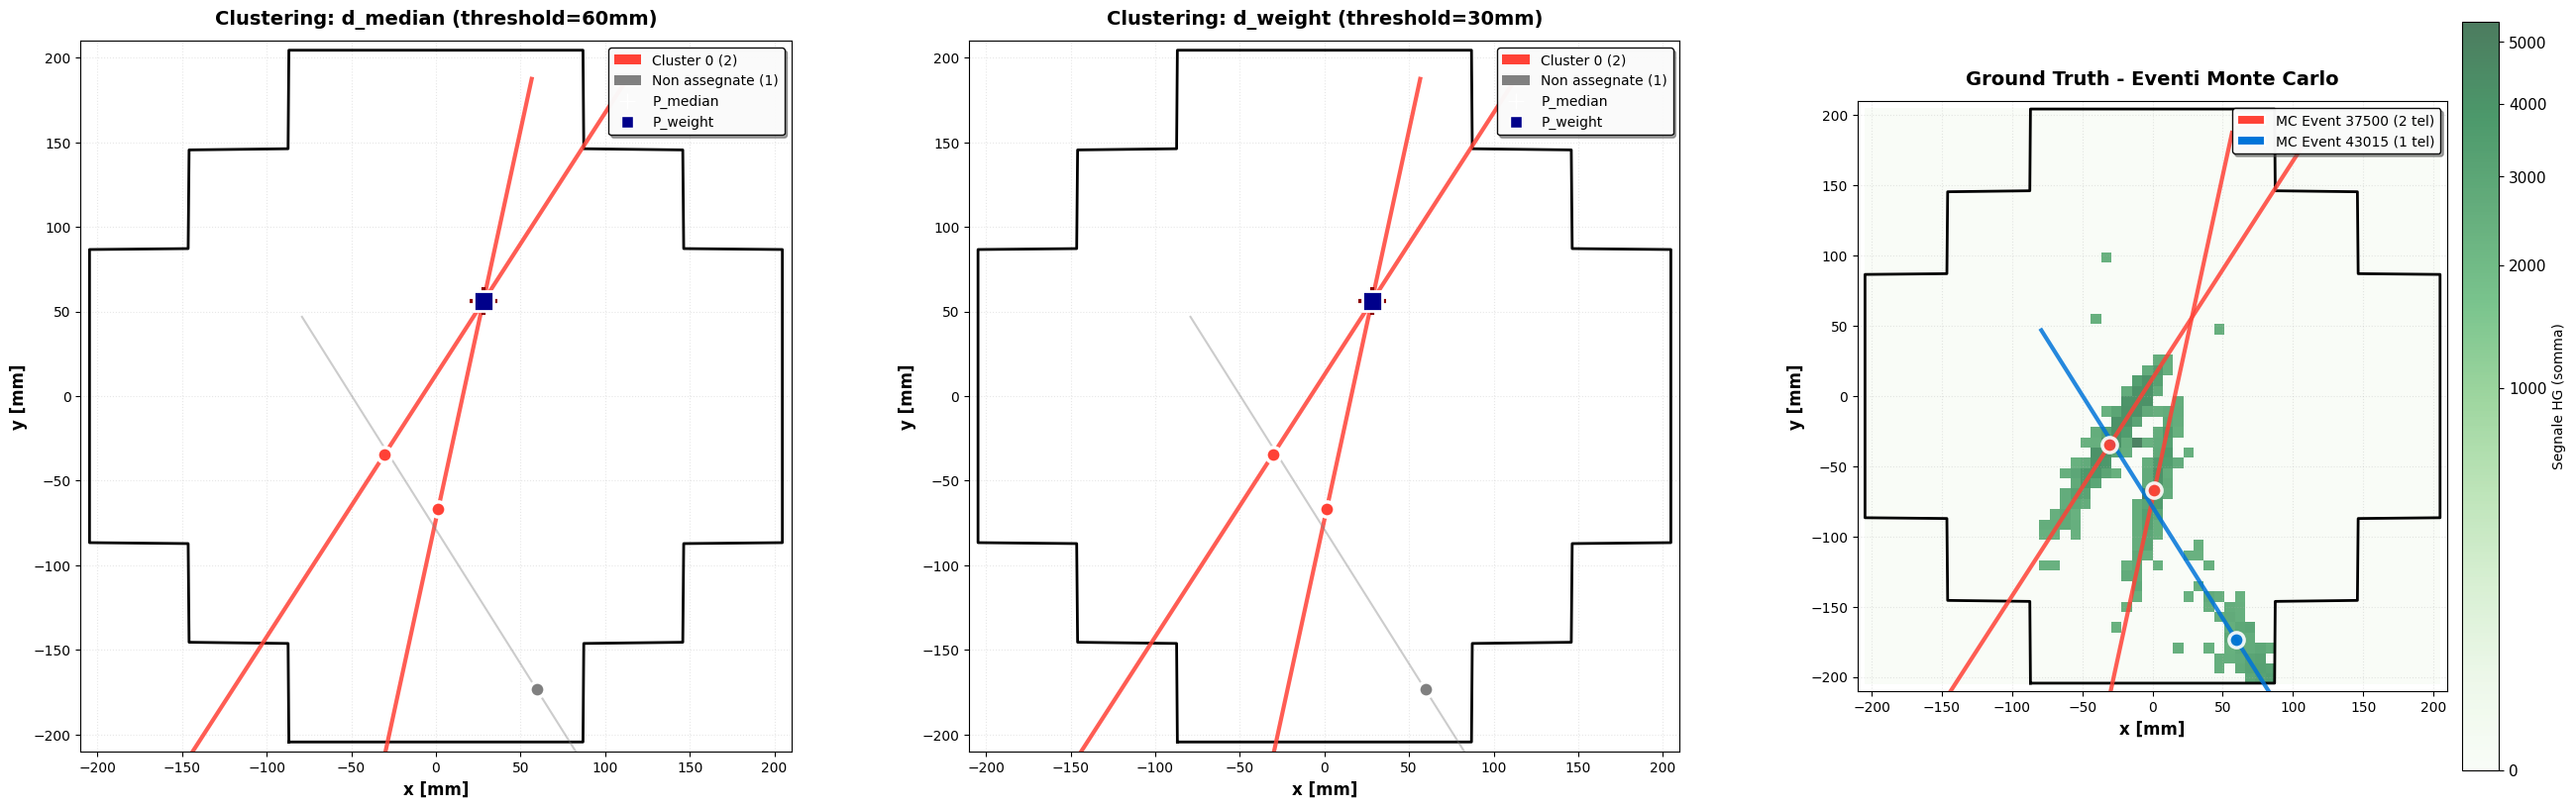

 time_group 45
  Rette totali: 3
  d_median: 3/3 corrette (100.0%)
  d_weight: 3/3 corrette (100.0%)

TIME GROUP 52
Telescopi: 4 | Eventi MC: [26709 44101] | MCRUN: [220007]
Cluster DBSCAN trovati: [0]


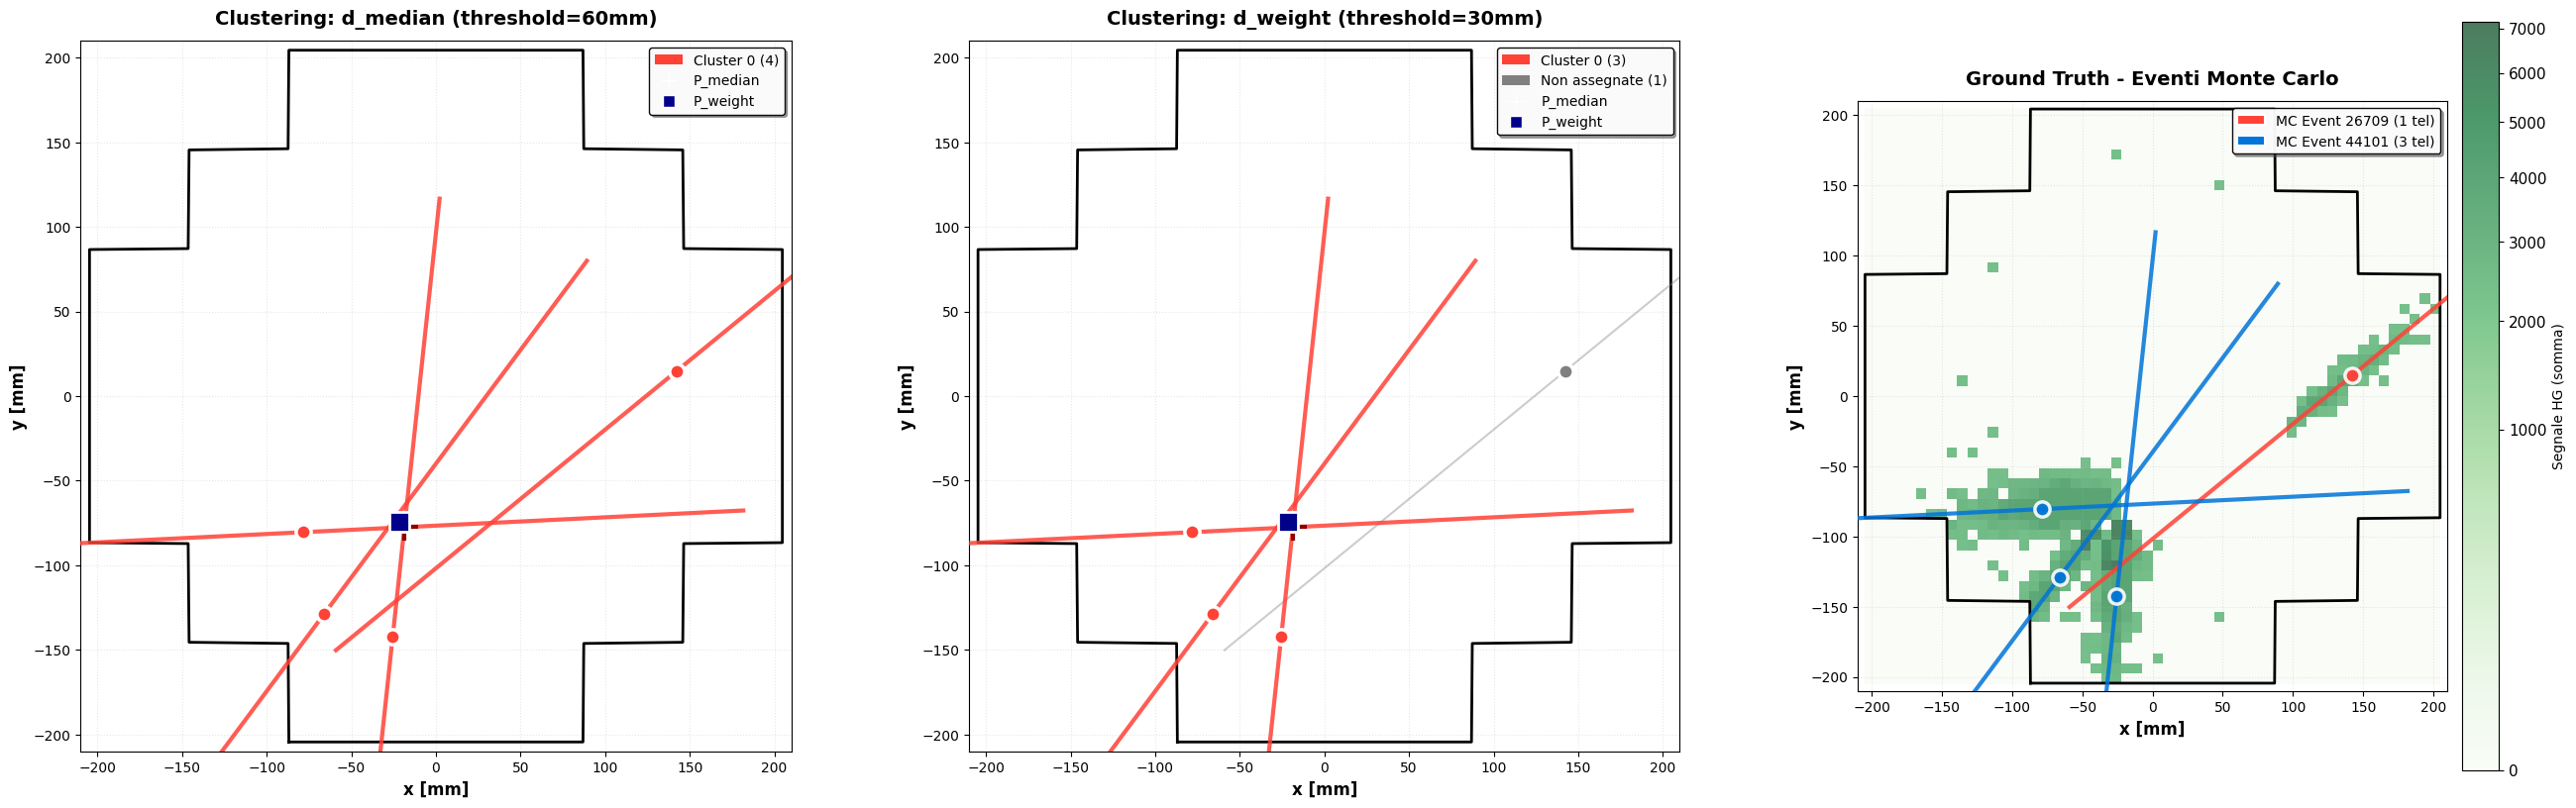

 time_group 52
  Rette totali: 4
  d_median: 0/4 corrette (0.0%)
  d_weight: 4/4 corrette (100.0%)

TIME GROUP 54
Telescopi: 3 | Eventi MC: [49716 49718] | MCRUN: [220007]
Cluster DBSCAN trovati: [0]


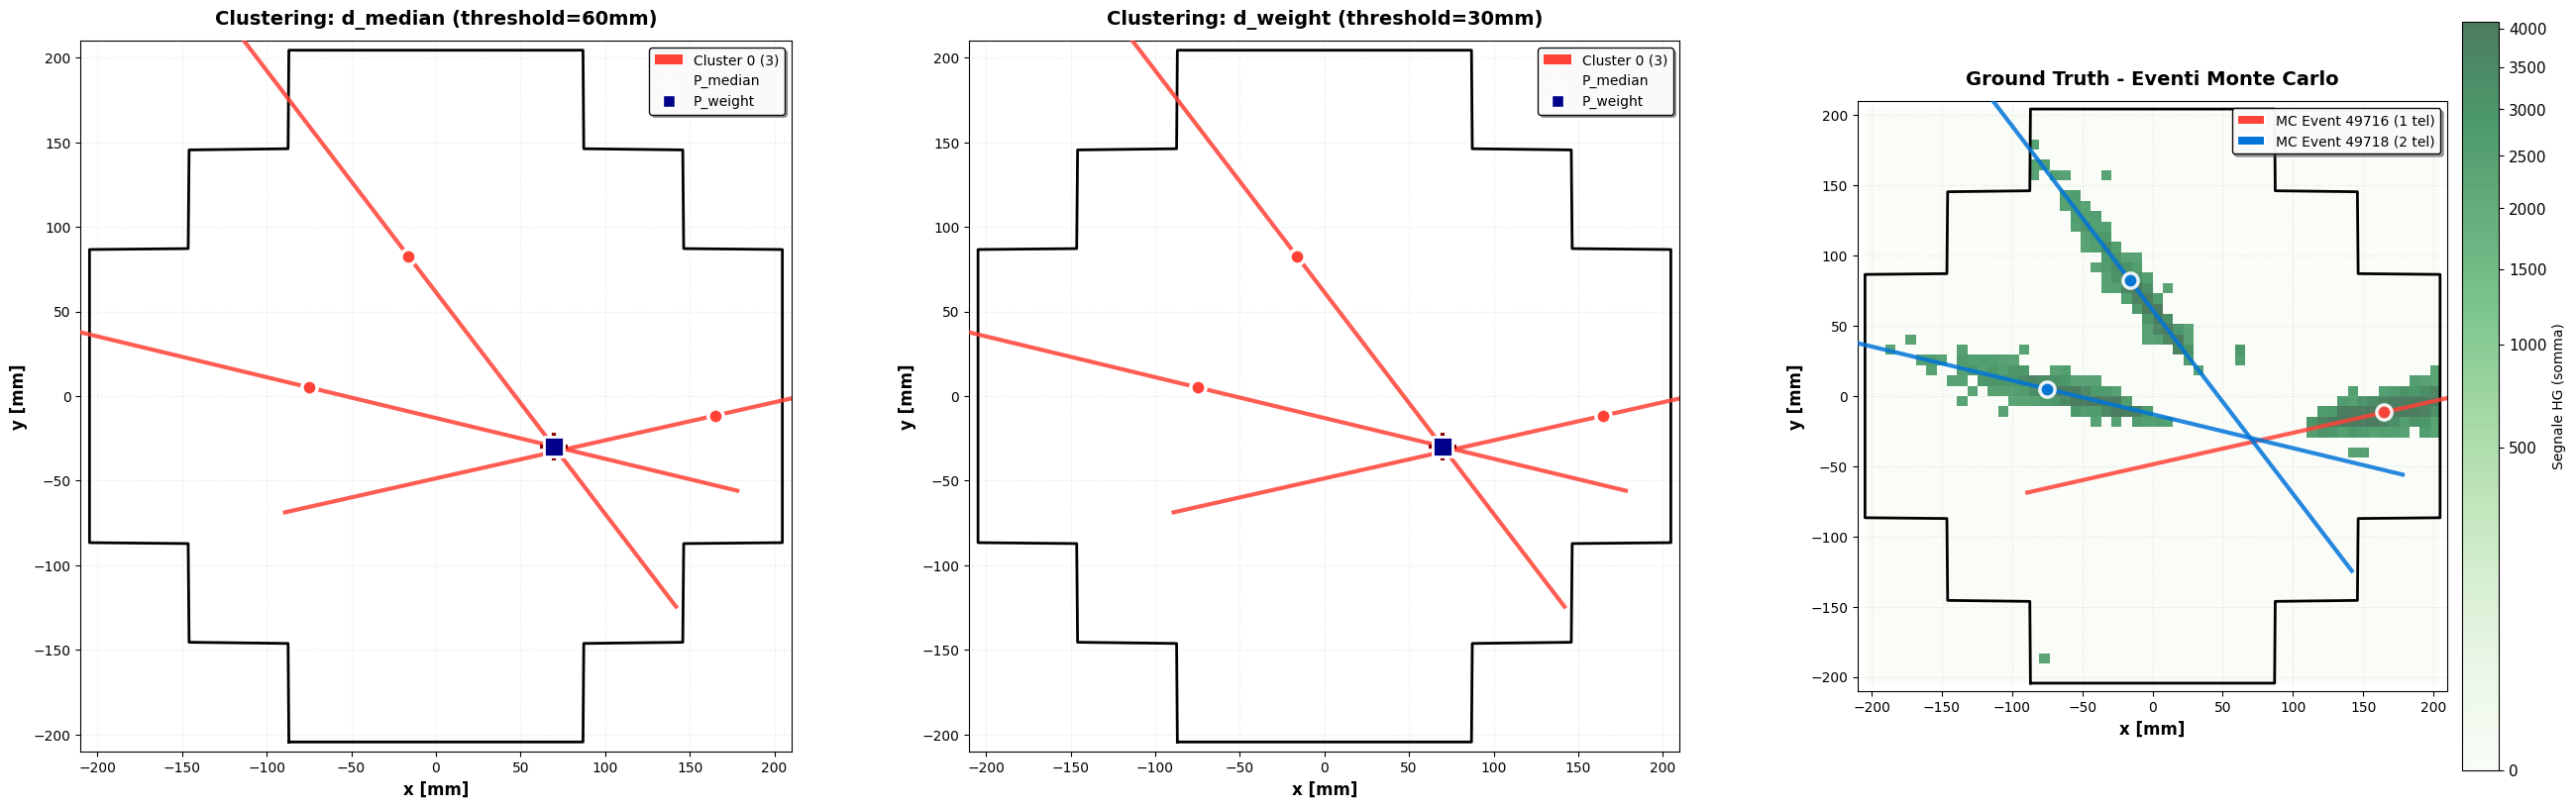

 time_group 54
  Rette totali: 3
  d_median: 0/3 corrette (0.0%)
  d_weight: 0/3 corrette (0.0%)

TIME GROUP 56
Telescopi: 3 | Eventi MC: [20417 23802] | MCRUN: [220008]
Cluster DBSCAN trovati: [0]


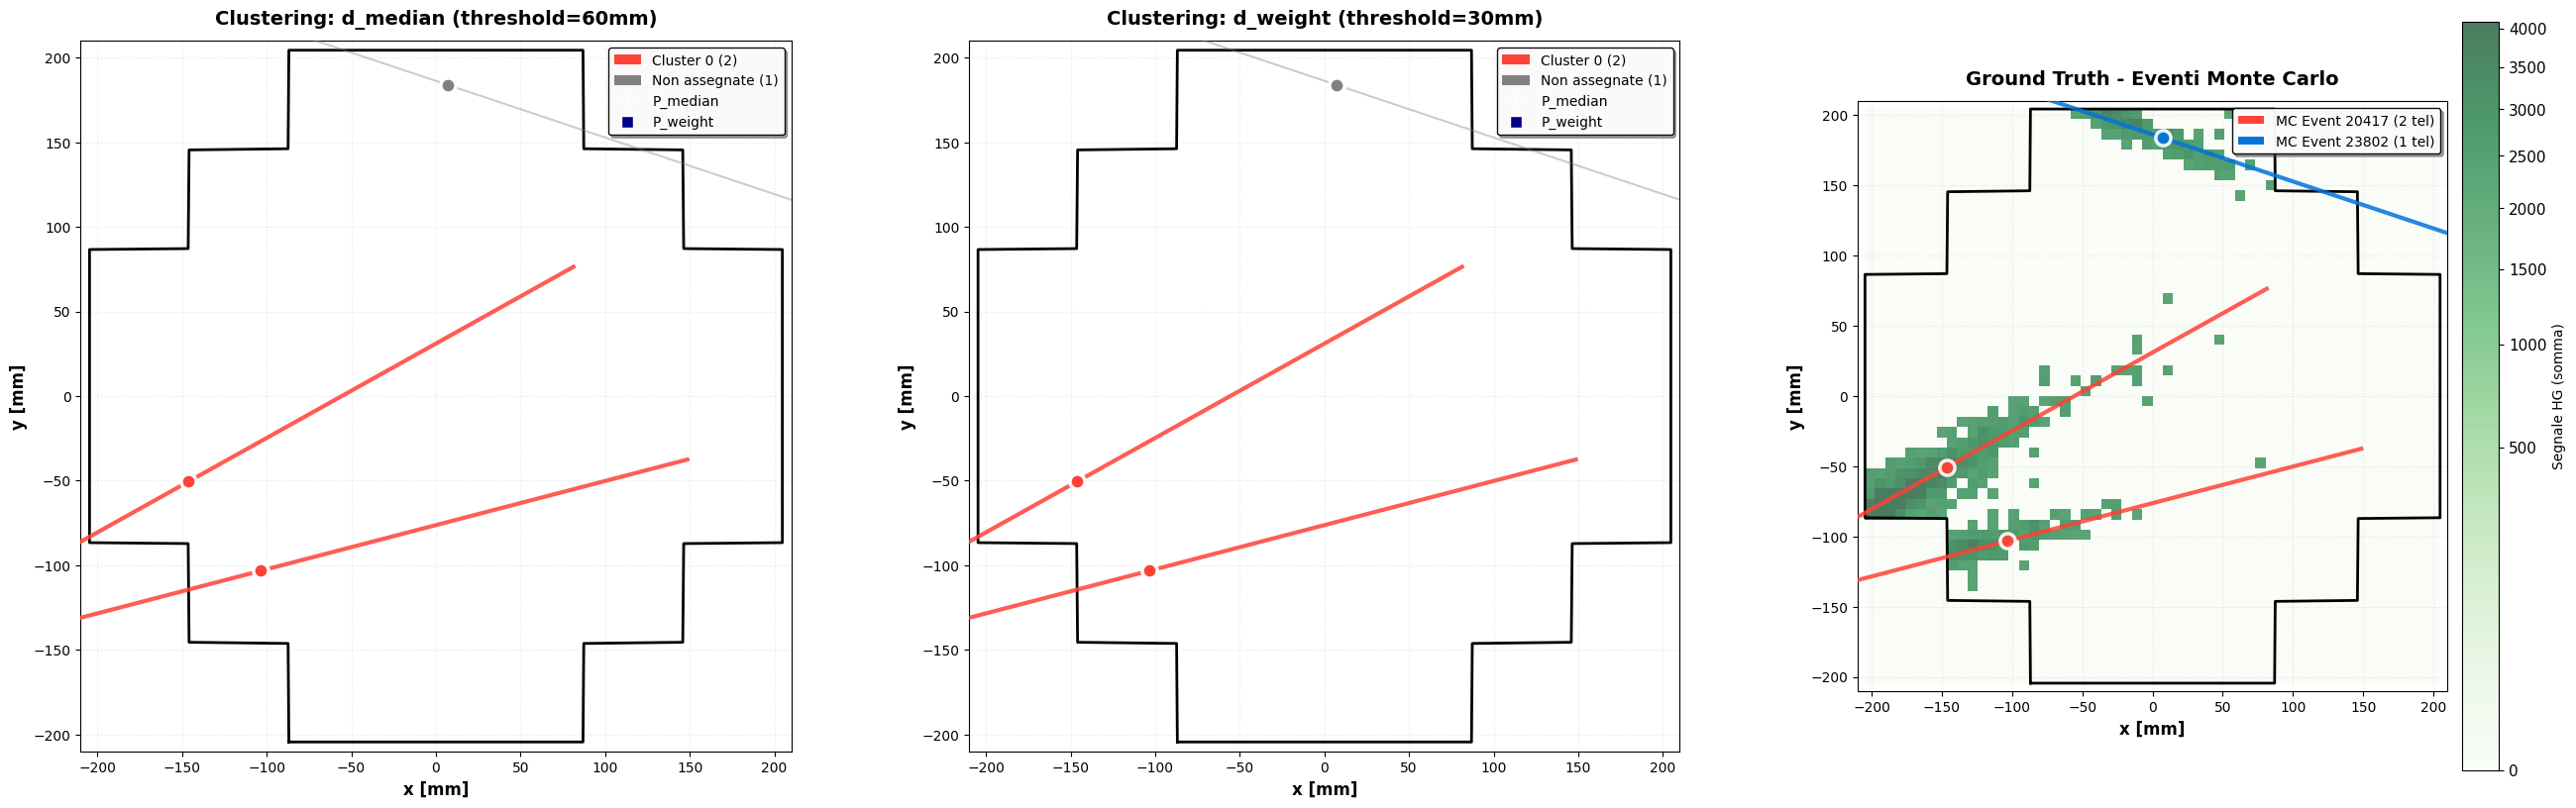

 time_group 56
  Rette totali: 3
  d_median: 3/3 corrette (100.0%)
  d_weight: 3/3 corrette (100.0%)

TIME GROUP 58
Telescopi: 4 | Eventi MC: [29213 29215] | MCRUN: [220008]
Cluster DBSCAN trovati: [0]


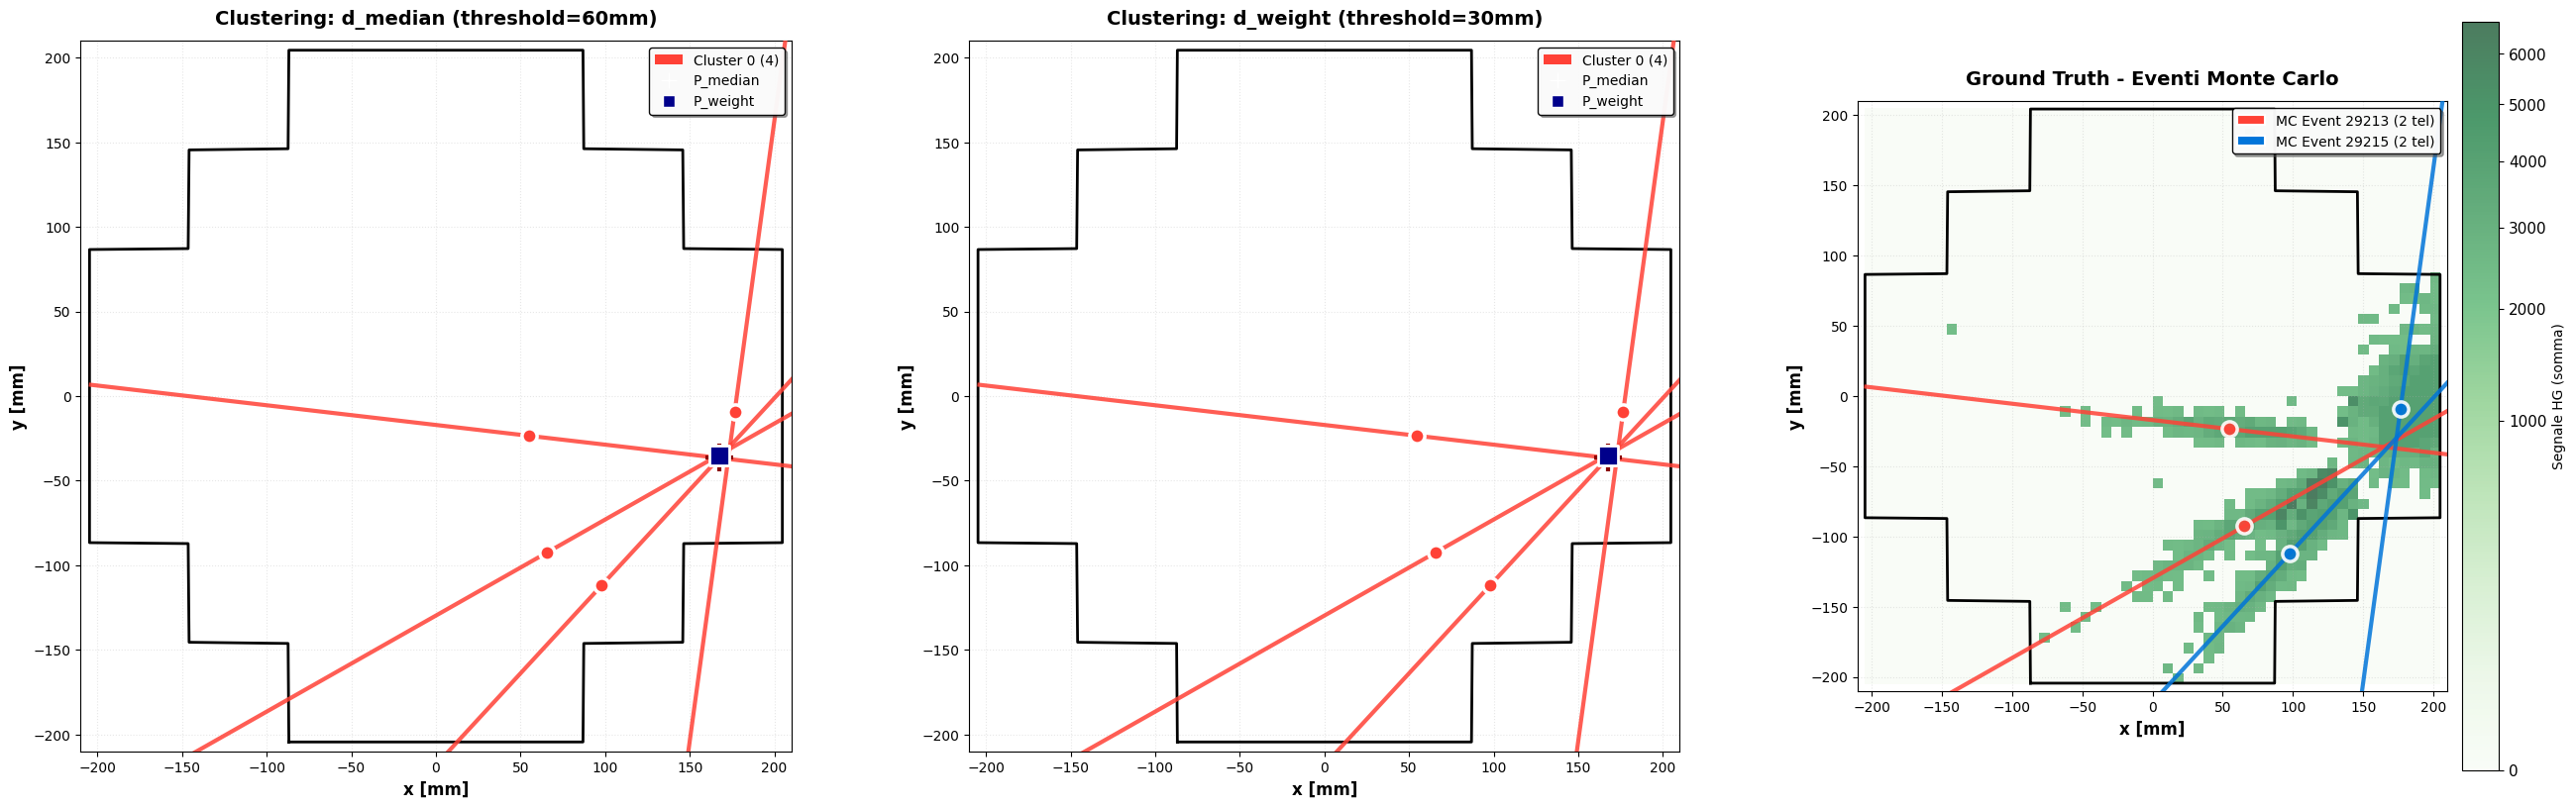

 time_group 58
  Rette totali: 4
  d_median: 0/4 corrette (0.0%)
  d_weight: 0/4 corrette (0.0%)


In [7]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import PowerNorm
from sklearn.cluster import DBSCAN
from collections import Counter
# Parametri
epsilon = 295
min_samples = 1
threshold_median = 60
threshold_weight = 30
centroid_distance_threshold = 25

xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

# Lunghezza rette
xmin, xmax = np.min(xfp), np.max(xfp)
ymin, ymax = np.min(yfp), np.max(yfp)
diag = np.sqrt((xmax - xmin)**2 + (ymax - ymin)**2)
L = 0.45 * diag

# =====================================================================
# CICLO PRINCIPALE SU TIME_GROUP
# =====================================================================

for time_group in dfR['time_group'].drop_duplicates().values[:20]:
    
    print(f"\n{'='*70}")
    print(f"TIME GROUP {time_group}")
    print(f"{'='*70}")
    
    # -----------------------------------------------------------------
    # 1. FILTRA DATI PER QUESTO TIME_GROUP
    # -----------------------------------------------------------------
    
    dfR_tg = dfR[dfR['time_group'] == time_group].copy()
    
    if len(dfR_tg) == 0:
        print(f"⚠ Nessuna retta per time_group {time_group}, skip.")
        continue
    
    # Estrai info evento
    unique_events = dfR_tg['event'].unique()
    unique_mcruns = dfR_tg['mcrun'].unique()
    
    print(f"Telescopi: {len(dfR_tg)} | Eventi MC: {unique_events} | MCRUN: {unique_mcruns}")
    
    # -----------------------------------------------------------------
    # 2. CALCOLA INTERSEZIONI HG
    # -----------------------------------------------------------------
    
    inters_hg = []
    rows = dfR_tg.to_dict('records')
    
    for i in range(len(rows)):
        for j in range(i+1, len(rows)):
            
            r1 = rows[i]["HG"]
            r2 = rows[j]["HG"]
            
            P = intersection(r1["p0"], r1["d"], r2["p0"], r2["d"])
            
            if P is None:
                continue
            dist_from_origin = np.linalg.norm(P)
            if dist_from_origin > 800:  # Fuori dalla zona ragionevole
                continue
            # NUOVO FILTRO: distanza dai baricentri
            # ============================================================
            dist_p0_1 = np.linalg.norm(P - r1["p0"])
            dist_p0_2 = np.linalg.norm(P - r2["p0"])
            diff_dist = np.abs(dist_p0_1 - dist_p0_2)
            
            if diff_dist > centroid_distance_threshold:
                continue  # Scarta questa intersezione
            n_pixels=rows[i]["n_pixels"]+rows[j]["n_pixels"]

            inters_hg.append({
                "tel1": r1["tel"],
                "tel2": r2["tel"],
                "event1": rows[i]["event"],
                "event2": rows[j]["event"],
                "mcrun1": rows[i]["mcrun"],
                "mcrun2": rows[j]["mcrun"],
                "d1": r1["d"],
                "d2": r2["d"],
                "P": P,
                "n_pixels":n_pixels
            })
    
    if len(inters_hg) == 0:
        print(f" Nessuna intersezione HG per time_group {time_group}, skip.")
        continue
    
    df_int_hg_tg = pd.DataFrame(inters_hg)
    P_all = np.vstack(df_int_hg_tg["P"].values)
    
    # -----------------------------------------------------------------
    # 3. CLUSTERING DBSCAN
    # -----------------------------------------------------------------
    
    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P_all)
    cluster_labels_dbscan = set(labels) - {-1}
    
    if len(cluster_labels_dbscan) == 0:
        print(f"Nessun cluster trovato per time_group {time_group}, skip.")
        continue
    
    print(f"Cluster DBSCAN trovati: {list(cluster_labels_dbscan)}")
    
    # -----------------------------------------------------------------
    # 4. CALCOLA DISTANZE RETTE-CLUSTER E BARICENTRI
    # -----------------------------------------------------------------
    
    # Crea dizionario tel -> (event, mcrun)
    tel_to_event = {}
    for _, row in dfR_tg.iterrows():
        tel_id = row["HG"]["tel"]
        tel_to_event[tel_id] = (row["event"], row["mcrun"])
    
    # Estrai parametri rette
    p0_all = np.vstack([r["p0"] for r in dfR_tg["HG"]])
    d_all = np.vstack([r["d"] for r in dfR_tg["HG"]])
    tel_all = np.array([r["tel"] for r in dfR_tg["HG"]])
    
    # Calcola baricentri e distanze per ogni cluster
    cluster_info = {}
    
    for lab in cluster_labels_dbscan:
        Pcl = P_all[labels == lab]
        dfP = df_int_hg_tg[labels == lab]
        max_pixels = dfR_tg['n_pixels'].max()
        # Calcolo pesi angolari
        w = []
        for _, row in dfP.iterrows():
            d1 = row["d1"]
            d2 = row["d2"]
            w_sin=((d1[0]*d2[1] - d1[1]*d2[0])**2)
            
            w_pix_norm = (row["n_pixels"] / (2 * max_pixels))**2
            w.append(np.sqrt(w_sin + w_pix_norm))
        w = np.array(w)
        
        # Baricentri
        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)
        
        # Distanze punto-retta per TUTTE le rette
        dist_median = d_punto_retta_vec(P_median, p0_all, d_all)
        dist_weight = d_punto_retta_vec(P_weight, p0_all, d_all)
        
        cluster_info[lab] = {
            'P_median': P_median,
            'P_weight': P_weight,
            'P_simple': P_simple,
            'dist_median': dist_median,
            'dist_weight': dist_weight
        }
    
    # -----------------------------------------------------------------
    # 5. ASSEGNAMENTI BASATI SU d_median (PANNELLO SINISTRO)
    # -----------------------------------------------------------------
    
    tel_assignments_median = {}
    
    for i, tel in enumerate(tel_all):
        best_cluster = -1
        min_dist = np.inf
        
        for lab in cluster_labels_dbscan:
            dist = cluster_info[lab]['dist_median'][i]
            if dist < min_dist:
                min_dist = dist
                best_cluster = lab
        
        if min_dist <= threshold_median:
            tel_assignments_median[tel] = {
                'cluster': best_cluster,
                'distance': min_dist,
                'is_assigned': True,
                'P_median': cluster_info[best_cluster]['P_median'],
                'P_weight': cluster_info[best_cluster]['P_weight']
            }
        else:
            tel_assignments_median[tel] = {
                'cluster': -1,
                'distance': min_dist,
                'is_assigned': False,
                'P_median': None,
                'P_weight': None
            }
    
    # -----------------------------------------------------------------
    # 6. ASSEGNAMENTI BASATI SU d_weight (PANNELLO CENTRALE)
    # -----------------------------------------------------------------
    
    tel_assignments_weight = {}
    
    for i, tel in enumerate(tel_all):
        best_cluster = -1
        min_dist = np.inf
        
        for lab in cluster_labels_dbscan:
            dist = cluster_info[lab]['dist_weight'][i]
            if dist < min_dist:
                min_dist = dist
                best_cluster = lab
        
        if min_dist <= threshold_weight:
            tel_assignments_weight[tel] = {
                'cluster': best_cluster,
                'distance': min_dist,
                'is_assigned': True,
                'P_median': cluster_info[best_cluster]['P_median'],
                'P_weight': cluster_info[best_cluster]['P_weight']
            }
        else:
            tel_assignments_weight[tel] = {
                'cluster': -1,
                'distance': min_dist,
                'is_assigned': False,
                'P_median': None,
                'P_weight': None
            }
    
    # -----------------------------------------------------------------
    # 7. CONFRONTO CON VERITÀ MONTE CARLO
    # -----------------------------------------------------------------
    
    # Conta quanti eventi MC ci sono
    n_eventi_mc = len(unique_events)
    
    # -----------------------------------------------------------------
    # 7. CONFRONTO CON VERITÀ MONTE CARLO (PER RETTA)
    # -----------------------------------------------------------------

    # Dizionario tel -> (event, mcrun)
    tel_to_truth = {
        row["HG"]["tel"]: (row["event"], row["mcrun"])
        for _, row in dfR_tg.iterrows()
    }

    # Conta quante volte compare ogni (event, mcrun)
    
    truth_counts = Counter(tel_to_truth.values())

    correct_median = 0
    total_median = len(tel_to_truth)

    # Raggruppa telescopi per cluster
    cluster_to_tels_median = {}
    for tel, ass in tel_assignments_median.items():
        if ass["is_assigned"]:
            cluster_to_tels_median.setdefault(ass["cluster"], []).append(tel)

    # Set dei telescopi assegnati
    assigned_tels_median = set(cluster_to_tels_median.keys())
    assigned_tels_median = set(tel for tels in cluster_to_tels_median.values() for tel in tels)

    #  Rette assegnate
    for cl, tels in cluster_to_tels_median.items():
        truths = [tel_to_truth[tel] for tel in tels]
        all_same = all(t == truths[0] for t in truths)

        for tel in tels:
            if all_same:
                correct_median += 1

    #  Rette NON assegnate
    for tel, truth in tel_to_truth.items():
        if tel not in assigned_tels_median:
            if truth_counts[truth] == 1:
                correct_median += 1

    # Per d_weight: stessa logica
    correct_weight = 0
    total_weight = len(tel_to_truth)

    cluster_to_tels_weight = {}
    for tel, ass in tel_assignments_weight.items():
        if ass["is_assigned"]:
            cluster_to_tels_weight.setdefault(ass["cluster"], []).append(tel)

    assigned_tels_weight = set(tel for tels in cluster_to_tels_weight.values() for tel in tels)

    # Rette assegnate
    for cl, tels in cluster_to_tels_weight.items():
        truths = [tel_to_truth[tel] for tel in tels]
        all_same = all(t == truths[0] for t in truths)

        for tel in tels:
            if all_same:
                correct_weight += 1

    # Rette non assegnate
    for tel, truth in tel_to_truth.items():
        if tel not in assigned_tels_weight:
            if truth_counts[truth] == 1:
                correct_weight += 1
    
    # -----------------------------------------------------------------
    # 8. PLOT 3 PANNELLI
    # -----------------------------------------------------------------
    
    fig, ax = plt.subplots(1, 3, figsize=(27, 9))
    
    # Colori per cluster
    cluster_trovati = list(cluster_labels_dbscan) + [-1]
    colori_cluster = {cluster_trovati[i]: ['#FF4136', '#0074D9', '#2ECC40', '#FF851B', '#B10DC9'][i % 5] 
                     for i in range(len(cluster_trovati))}
    colori_cluster[-1] = 'gray'
    
    # Colori per eventi MC
    colors_mc = ['#FF4136', '#0074D9', '#2ECC40', '#FF851B']
    event_color_map = {unique_events[i]: colors_mc[i % len(colors_mc)] for i in range(len(unique_events))}
    
    # Contatori
    rette_per_cluster_median = {c: 0 for c in cluster_trovati}
    rette_per_cluster_weight = {c: 0 for c in cluster_trovati}
    rette_per_evento = {ev: 0 for ev in unique_events}
    
    # Array per heatmap (pannello destro)
    weights_hg = np.zeros((37, 64))
    mask_tot = np.zeros((37, 64), dtype=bool)
    
    # Baricentri già plottati
    baricentri_plottati_median = set()
    baricentri_plottati_weight = set()
    
    # -----------------------------------------------------------------
    # PANNELLO SINISTRO: CLUSTERING con d_median (threshold=60)
    # -----------------------------------------------------------------
    
    for _, row in dfR_tg.iterrows():
        
        tel_id = row["HG"]["tel"]
        p0 = row["HG"]["p0"]
        d = row["HG"]["d"]
        event = row["event"]
        
        meanx = p0[0]
        meany = p0[1]
        theta = np.arctan2(d[1], d[0])
        
        # Coordinate retta
        x1 = meanx - L * np.cos(theta)
        y1 = meany - L * np.sin(theta)
        x2 = meanx + L * np.cos(theta)
        y2 = meany + L * np.sin(theta)
        
        assignment = tel_assignments_median.get(tel_id)
        
        if assignment and assignment['is_assigned']:
            cluster_id = assignment['cluster']
            col = colori_cluster[cluster_id]
            alpha = 0.85
            lw = 3.0
            rette_per_cluster_median[cluster_id] += 1
            
            # Plotta baricentri (una sola volta per cluster)
            if cluster_id not in baricentri_plottati_median:
                P_median = assignment['P_median']
                P_weight = assignment['P_weight']
                
                ax[0].scatter(P_median[0], P_median[1], marker='+', s=400, c='darkred', 
                            linewidth=3, zorder=7)
                ax[0].scatter(P_weight[0], P_weight[1], marker='s', s=200, c='darkblue', 
                            linewidth=2, zorder=7, edgecolor='white')
                baricentri_plottati_median.add(cluster_id)
        else:
            col = 'gray'
            alpha = 0.4
            lw = 1.5
            rette_per_cluster_median[-1] += 1
        
        ax[0].plot([x1, x2], [y1, y2], color=col, linewidth=lw, alpha=alpha, zorder=5)
        ax[0].scatter(meanx, meany, s=120, color=col, edgecolor='white', linewidth=2.5, zorder=6)
    
    # -----------------------------------------------------------------
    # PANNELLO CENTRALE: CLUSTERING con d_weight (threshold=30)
    # -----------------------------------------------------------------
    
    for _, row in dfR_tg.iterrows():
        
        tel_id = row["HG"]["tel"]
        p0 = row["HG"]["p0"]
        d = row["HG"]["d"]
        event = row["event"]
        
        meanx = p0[0]
        meany = p0[1]
        theta = np.arctan2(d[1], d[0])
        
        # Coordinate retta
        x1 = meanx - L * np.cos(theta)
        y1 = meany - L * np.sin(theta)
        x2 = meanx + L * np.cos(theta)
        y2 = meany + L * np.sin(theta)
        
        assignment = tel_assignments_weight.get(tel_id)
        
        if assignment and assignment['is_assigned']:
            cluster_id = assignment['cluster']
            col = colori_cluster[cluster_id]
            alpha = 0.85
            lw = 3.0
            rette_per_cluster_weight[cluster_id] += 1
            
            # Plotta baricentri (una sola volta per cluster)
            if cluster_id not in baricentri_plottati_weight:
                P_median = assignment['P_median']
                P_weight = assignment['P_weight']
                
                ax[1].scatter(P_median[0], P_median[1], marker='+', s=400, c='darkred', 
                            linewidth=3, zorder=7)
                ax[1].scatter(P_weight[0], P_weight[1], marker='s', s=200, c='darkblue', 
                            linewidth=2, zorder=7, edgecolor='white')
                baricentri_plottati_weight.add(cluster_id)
        else:
            col = 'gray'
            alpha = 0.4
            lw = 1.5
            rette_per_cluster_weight[-1] += 1
        
        ax[1].plot([x1, x2], [y1, y2], color=col, linewidth=lw, alpha=alpha, zorder=5)
        ax[1].scatter(meanx, meany, s=120, color=col, edgecolor='white', linewidth=2.5, zorder=6)
    
    # -----------------------------------------------------------------
    # PANNELLO DESTRO: GROUND TRUTH MC
    # -----------------------------------------------------------------
    
    for _, row in dfR_tg.iterrows():
        
        tel_id = row["HG"]["tel"]
        p0 = row["HG"]["p0"]
        d = row["HG"]["d"]
        event = row["event"]
        
        meanx = p0[0]
        meany = p0[1]
        theta = np.arctan2(d[1], d[0])
        
        # Coordinate retta
        x1 = meanx - L * np.cos(theta)
        y1 = meany - L * np.sin(theta)
        x2 = meanx + L * np.cos(theta)
        y2 = meany + L * np.sin(theta)
        
        # Recupera HG, TTP per heatmap
        mask_tel = (df_linked_events['time_group'] == time_group) & (df_linked_events['TEL_ID'] == tel_id)
        
        if mask_tel.sum() > 0:
            row_data = df_linked_events[mask_tel].iloc[0]
            
            hgev = np.array(row_data['HG'])
            ttpev = np.array(row_data['TTP'])
            pxmask = (hgev > 2400) & (ttpev < 255)
            
            if np.any(pxmask):
                weights_hg[pxmask] += hgev[pxmask]
                mask_tot |= pxmask
        
        color_ev = event_color_map[event]
        rette_per_evento[event] += 1
        
        ax[2].scatter(meanx, meany, s=120, color=color_ev, 
                     edgecolor='white', linewidth=2.5, zorder=6, alpha=0.9)
        ax[2].plot([x1, x2], [y1, y2], color=color_ev, linewidth=3, alpha=0.85, zorder=5)
    
    # Heatmap
    if np.any(mask_tot):
        h1 = ax[2].hist2d(x_pix[mask_tot].flatten(), y_pix[mask_tot].flatten(),
                         weights=weights_hg[mask_tot].flatten(), 
                         range=((-205, 205), (-205, 205)),
                         bins=7*8, cmap='Greens', alpha=0.7, norm=PowerNorm(0.4))
        
        cbar1 = fig.colorbar(h1[3], ax=ax[2], label='Segnale HG (somma)', pad=0.02)
        cbar1.ax.tick_params(labelsize=11)
    
    # -----------------------------------------------------------------
    # FORMATTAZIONE ASSI (LIMITI FISSI A 210)
    # -----------------------------------------------------------------
    
    for a in ax:
        a.plot(xfp, yfp, 'k-', linewidth=2, zorder=2)
        a.set_xlim(-210, 210)
        a.set_ylim(-210, 210)
        a.set_aspect('equal')
        a.set_xlabel('x [mm]', fontsize=12, fontweight='bold')
        a.set_ylabel('y [mm]', fontsize=12, fontweight='bold')
        a.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
    
    ax[0].set_title('Clustering: d_median (threshold=60mm)', fontweight='bold', fontsize=14, pad=12)
    ax[1].set_title('Clustering: d_weight (threshold=30mm)', fontweight='bold', fontsize=14, pad=12)
    ax[2].set_title('Ground Truth - Eventi Monte Carlo', fontweight='bold', fontsize=14, pad=12)
    
    # -----------------------------------------------------------------
    # LEGGENDE
    # -----------------------------------------------------------------
    
    # Legenda sinistra (d_median)
    legend_median = []
    for c in sorted([k for k in cluster_trovati if k != -1]):
        if rette_per_cluster_median.get(c, 0) > 0:
            legend_median.append(Patch(facecolor=colori_cluster[c], 
                                      label=f'Cluster {c} ({rette_per_cluster_median[c]})'))
    if rette_per_cluster_median.get(-1, 0) > 0:
        legend_median.append(Patch(facecolor='gray', 
                                  label=f'Non assegnate ({rette_per_cluster_median[-1]})'))
    
    legend_median.append(Line2D([0], [0], marker='+', color='w', markerfacecolor='darkred', 
                               markersize=12, label='P_median', linewidth=0))
    legend_median.append(Line2D([0], [0], marker='s', color='w', markerfacecolor='darkblue', 
                               markersize=8, label='P_weight', linewidth=0, markeredgecolor='white'))
    
    ax[0].legend(handles=legend_median, loc='upper right', fontsize=10, 
                framealpha=0.95, edgecolor='black', fancybox=True, shadow=True)
    
    # Legenda centro (d_weight)
    legend_weight = []
    for c in sorted([k for k in cluster_trovati if k != -1]):
        if rette_per_cluster_weight.get(c, 0) > 0:
            legend_weight.append(Patch(facecolor=colori_cluster[c], 
                                      label=f'Cluster {c} ({rette_per_cluster_weight[c]})'))
    if rette_per_cluster_weight.get(-1, 0) > 0:
        legend_weight.append(Patch(facecolor='gray', 
                                  label=f'Non assegnate ({rette_per_cluster_weight[-1]})'))
    
    legend_weight.append(Line2D([0], [0], marker='+', color='w', markerfacecolor='darkred', 
                               markersize=12, label='P_median', linewidth=0))
    legend_weight.append(Line2D([0], [0], marker='s', color='w', markerfacecolor='darkblue', 
                               markersize=8, label='P_weight', linewidth=0, markeredgecolor='white'))
    
    ax[1].legend(handles=legend_weight, loc='upper right', fontsize=10, 
                framealpha=0.95, edgecolor='black', fancybox=True, shadow=True)
    
    # Legenda destra (eventi MC)
    legend_mc = [
        Patch(facecolor=event_color_map[ev], edgecolor='white', linewidth=1.5,
              label=f'MC Event {ev} ({rette_per_evento[ev]} tel)')
        for ev in unique_events
    ]
    ax[2].legend(handles=legend_mc, loc='upper right', fontsize=10, 
                framealpha=0.95, edgecolor='black', fancybox=True, shadow=True)
    
    
    plt.subplots_adjust(top=0.92, bottom=0.08, left=0.05, right=0.98, wspace=0.25)
    plt.show()
    
    # -----------------------------------------------------------------
    # STAMPA SUMMARY
    # -----------------------------------------------------------------
    
    acc_median = 100 * correct_median / total_median
    acc_weight = 100 * correct_weight / total_weight

    print(f" time_group {time_group}")
    print(f"  Rette totali: {total_median}")
    print(f"  d_median: {correct_median}/{total_median} corrette ({acc_median:.1f}%)")
    print(f"  d_weight: {correct_weight}/{total_weight} corrette ({acc_weight:.1f}%)")


In [11]:
def evaluate_reconstruction(tel_assignments, tel_to_truth, cluster_labels_dbscan):
    """
    Valuta se la ricostruzione è perfetta per questo time_group.
    
    Returns:
        bool: True se TUTTI gli eventi MC sono stati ricostruiti perfettamente
        dict: Dettagli della ricostruzione
    """
    # Raggruppa telescopi per cluster
    cluster_to_tels = {}
    unassigned_tels = []
    
    for tel, ass in tel_assignments.items():
        if ass["is_assigned"]:
            cluster_id = ass["cluster"]
            cluster_to_tels.setdefault(cluster_id, []).append(tel)
        else:
            unassigned_tels.append(tel)
    
    # Verifica purezza di ogni cluster ASSEGNATO
    all_clusters_pure = True
    cluster_purity = {}
    
    for cluster_id, tels in cluster_to_tels.items():
        truths = [tel_to_truth[tel] for tel in tels]
        unique_truths = set(truths)
        
        is_pure = len(unique_truths) == 1
        cluster_purity[cluster_id] = {
            'is_pure': is_pure,
            'n_tels': len(tels),
            'events': list(unique_truths)
        }
        
        if not is_pure:
            all_clusters_pure = False
    
    # Verifica rette non assegnate (devono essere tutte di eventi singoli)
    unassigned_pure = True
    unassigned_details = {}
    
    if unassigned_tels:
        unassigned_truths = [tel_to_truth[tel] for tel in unassigned_tels]
        truth_counts = Counter(tel_to_truth.values())
        
        for tel in unassigned_tels:
            truth = tel_to_truth[tel]
            # Una retta non assegnata è "corretta" solo se è l'unica del suo evento
            if truth_counts[truth] > 1:
                unassigned_pure = False
                break
    
    # Verifica completezza: ogni evento MC deve stare in UN SOLO cluster (o non assegnato se singolo)
    event_distribution = {}
    for tel, truth in tel_to_truth.items():
        assignment = tel_assignments[tel]
        cluster_id = assignment['cluster'] if assignment['is_assigned'] else 'unassigned'
        
        event_distribution.setdefault(truth, set()).add(cluster_id)
    
    all_events_complete = all(len(clusters) == 1 for clusters in event_distribution.values())
    
    # Successo SOLO se:
    # 1. Tutti i cluster sono puri
    # 2. Tutte le rette non assegnate sono singole
    # 3. Ogni evento MC sta in un solo cluster/unassigned
    is_perfect = all_clusters_pure and unassigned_pure and all_events_complete
    
    details = {
        'is_perfect': is_perfect,
        'n_clusters': len(cluster_to_tels),
        'n_unassigned': len(unassigned_tels),
        'cluster_purity': cluster_purity,
        'unassigned_pure': unassigned_pure,
        'event_distribution': event_distribution,
        'all_events_complete': all_events_complete
    }
    
    return is_perfect, details


# =====================================================================
# ANALISI STATISTICA SU TUTTI I TIME_GROUP
# =====================================================================

results_median = []
results_weight = []

for time_group in dfR['time_group'].drop_duplicates().values:  # Rimuovi [:20] per tutti
    
    dfR_tg = dfR[dfR['time_group'] == time_group].copy()
    
    if len(dfR_tg) == 0:
        continue
    
    # Calcola intersezioni HG
    inters_hg = []
    rows = dfR_tg.to_dict('records')
    
    for i in range(len(rows)):
        for j in range(i+1, len(rows)):
            r1 = rows[i]["HG"]
            r2 = rows[j]["HG"]
            
            P = intersection(r1["p0"], r1["d"], r2["p0"], r2["d"])
            
            if P is None:
                continue
            dist_from_origin = np.linalg.norm(P)
            if dist_from_origin > 800:
                continue
            
            dist_p0_1 = np.linalg.norm(P - r1["p0"])
            dist_p0_2 = np.linalg.norm(P - r2["p0"])
            diff_dist = np.abs(dist_p0_1 - dist_p0_2)
            
            if diff_dist > centroid_distance_threshold:
                continue
            
            n_pixels = rows[i]["n_pixels"] + rows[j]["n_pixels"]
            
            inters_hg.append({
                "tel1": r1["tel"],
                "tel2": r2["tel"],
                "event1": rows[i]["event"],
                "event2": rows[j]["event"],
                "mcrun1": rows[i]["mcrun"],
                "mcrun2": rows[j]["mcrun"],
                "d1": r1["d"],
                "d2": r2["d"],
                "P": P,
                "n_pixels": n_pixels
            })
    
    if len(inters_hg) == 0:
        continue
    
    df_int_hg_tg = pd.DataFrame(inters_hg)
    P_all = np.vstack(df_int_hg_tg["P"].values)
    
    # DBSCAN
    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P_all)
    cluster_labels_dbscan = set(labels) - {-1}
    
    if len(cluster_labels_dbscan) == 0:
        continue
    
    # Ground truth
    tel_to_truth = {
        row["HG"]["tel"]: (row["event"], row["mcrun"])
        for _, row in dfR_tg.iterrows()
    }
    
    # Estrai parametri rette
    p0_all = np.vstack([r["p0"] for r in dfR_tg["HG"]])
    d_all = np.vstack([r["d"] for r in dfR_tg["HG"]])
    tel_all = np.array([r["tel"] for r in dfR_tg["HG"]])
    
    # Calcola baricentri e distanze
    cluster_info = {}
    
    for lab in cluster_labels_dbscan:
        Pcl = P_all[labels == lab]
        dfP = df_int_hg_tg[labels == lab]
        max_pixels = dfR_tg['n_pixels'].max()
        
        w = []
        for _, row in dfP.iterrows():
            d1 = row["d1"]
            d2 = row["d2"]
            w_sin = ((d1[0]*d2[1] - d1[1]*d2[0])**2)
            w_pix_norm = (row["n_pixels"] / (2 * max_pixels))**2
            w.append(np.sqrt(w_sin + w_pix_norm))
        w = np.array(w)
        
        P_median = np.median(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        
        dist_median = d_punto_retta_vec(P_median, p0_all, d_all)
        dist_weight = d_punto_retta_vec(P_weight, p0_all, d_all)
        
        cluster_info[lab] = {
            'P_median': P_median,
            'P_weight': P_weight,
            'dist_median': dist_median,
            'dist_weight': dist_weight
        }
    
    # ASSEGNAMENTI d_median
    tel_assignments_median = {}
    for i, tel in enumerate(tel_all):
        best_cluster = -1
        min_dist = np.inf
        
        for lab in cluster_labels_dbscan:
            dist = cluster_info[lab]['dist_median'][i]
            if dist < min_dist:
                min_dist = dist
                best_cluster = lab
        
        if min_dist <= threshold_median:
            tel_assignments_median[tel] = {
                'cluster': best_cluster,
                'distance': min_dist,
                'is_assigned': True
            }
        else:
            tel_assignments_median[tel] = {
                'cluster': -1,
                'distance': min_dist,
                'is_assigned': False
            }
    
    # ASSEGNAMENTI d_weight
    tel_assignments_weight = {}
    for i, tel in enumerate(tel_all):
        best_cluster = -1
        min_dist = np.inf
        
        for lab in cluster_labels_dbscan:
            dist = cluster_info[lab]['dist_weight'][i]
            if dist < min_dist:
                min_dist = dist
                best_cluster = lab
        
        if min_dist <= threshold_weight:
            tel_assignments_weight[tel] = {
                'cluster': best_cluster,
                'distance': min_dist,
                'is_assigned': True
            }
        else:
            tel_assignments_weight[tel] = {
                'cluster': -1,
                'distance': min_dist,
                'is_assigned': False
            }
    
    # VALUTAZIONE
    is_perfect_median, details_median = evaluate_reconstruction(
        tel_assignments_median, tel_to_truth, cluster_labels_dbscan
    )
    
    is_perfect_weight, details_weight = evaluate_reconstruction(
        tel_assignments_weight, tel_to_truth, cluster_labels_dbscan
    )
    
    unique_events = dfR_tg['event'].unique()
    n_events = len(unique_events)
    n_telescopes = len(tel_all)
    
    results_median.append({
        'time_group': time_group,
        'is_perfect': is_perfect_median,
        'n_events': n_events,
        'n_telescopes': n_telescopes,
        'n_clusters': details_median['n_clusters'],
        'n_unassigned': details_median['n_unassigned']
    })
    
    results_weight.append({
        'time_group': time_group,
        'is_perfect': is_perfect_weight,
        'n_events': n_events,
        'n_telescopes': n_telescopes,
        'n_clusters': details_weight['n_clusters'],
        'n_unassigned': details_weight['n_unassigned']
    })

# =====================================================================
# STAMPA RISULTATI FINALI
# =====================================================================

df_results_median = pd.DataFrame(results_median)
df_results_weight = pd.DataFrame(results_weight)

print("\n" + "="*70)
print("RISULTATI FINALI - CONFRONTO METODI")
print("="*70)

n_total = len(df_results_median)
n_perfect_median = df_results_median['is_perfect'].sum()
n_perfect_weight = df_results_weight['is_perfect'].sum()

success_rate_median = 100 * n_perfect_median / n_total if n_total > 0 else 0
success_rate_weight = 100 * n_perfect_weight / n_total if n_total > 0 else 0

print(f"\n METODO d_median (threshold={threshold_median}mm):")
print(f"   Ricostruzioni perfette: {n_perfect_median}/{n_total} ({success_rate_median:.1f}%)")

print(f"\n METODO d_weight (threshold={threshold_weight}mm):")
print(f"   Ricostruzioni perfette: {n_perfect_weight}/{n_total} ({success_rate_weight:.1f}%)")

print(f"\n{'='*70}")

# Statistiche aggiuntive
print("\n STATISTICHE AGGIUNTIVE:")
print(f"\nDistribuzione eventi per time_group:")
print(df_results_median['n_events'].value_counts().sort_index())

print(f"\nMedia telescopi per time_group: {df_results_median['n_telescopes'].mean():.1f}")
print(f"Media cluster identificati (d_median): {df_results_median['n_clusters'].mean():.1f}")
print(f"Media cluster identificati (d_weight): {df_results_weight['n_clusters'].mean():.1f}")



RISULTATI FINALI - CONFRONTO METODI

 METODO d_median (threshold=60mm):
   Ricostruzioni perfette: 114/412 (27.7%)

 METODO d_weight (threshold=30mm):
   Ricostruzioni perfette: 102/412 (24.8%)


 STATISTICHE AGGIUNTIVE:

Distribuzione eventi per time_group:
n_events
2    412
Name: count, dtype: int64

Media telescopi per time_group: 5.1
Media cluster identificati (d_median): 1.1
Media cluster identificati (d_weight): 1.1
